# **New York City Yellow Taxi Data**

## Objective
In this case study you will be learning exploratory data analysis (EDA) with the help of a dataset on yellow taxi rides in New York City. This will enable you to understand why EDA is an important step in the process of data science and machine learning.

## **Problem Statement**
As an analyst at an upcoming taxi operation in NYC, you are tasked to use the 2023 taxi trip data to uncover insights that could help optimise taxi operations. The goal is to analyse patterns in the data that can inform strategic decisions to improve service efficiency, maximise revenue, and enhance passenger experience.

## Tasks
You need to perform the following steps for successfully completing this assignment:
1. Data Loading
2. Data Cleaning
3. Exploratory Analysis: Bivariate and Multivariate
4. Creating Visualisations to Support the Analysis
5. Deriving Insights and Stating Conclusions

---

**NOTE:** The marks given along with headings and sub-headings are cumulative marks for those particular headings/sub-headings.<br>

The actual marks for each task are specified within the tasks themselves.

For example, marks given with heading *2* or sub-heading *2.1* are the cumulative marks, for your reference only. <br>

The marks you will receive for completing tasks are given with the tasks.

Suppose the marks for two tasks are: 3 marks for 2.1.1 and 2 marks for 3.2.2, or
* 2.1.1 [3 marks]
* 3.2.2 [2 marks]

then, you will earn 3 marks for completing task 2.1.1 and 2 marks for completing task 3.2.2.


---

## Data Understanding
The yellow taxi trip records include fields capturing pick-up and drop-off dates/times, pick-up and drop-off locations, trip distances, itemized fares, rate types, payment types, and driver-reported passenger counts.

The data is stored in Parquet format (*.parquet*). The dataset is from 2009 to 2024. However, for this assignment, we will only be using the data from 2023.

The data for each month is present in a different parquet file. You will get twelve files for each of the months in 2023.

The data was collected and provided to the NYC Taxi and Limousine Commission (TLC) by technology providers like vendors and taxi hailing apps. <br>

You can find the link to the TLC trip records page here: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

###  Data Description
You can find the data description here: [Data Dictionary](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf)

**Trip Records**



|Field Name       |description |
|:----------------|:-----------|
| VendorID | A code indicating the TPEP provider that provided the record. <br> 1= Creative Mobile Technologies, LLC; <br> 2= VeriFone Inc. |
| tpep_pickup_datetime | The date and time when the meter was engaged.  |
| tpep_dropoff_datetime | The date and time when the meter was disengaged.   |
| Passenger_count | The number of passengers in the vehicle. <br> This is a driver-entered value. |
| Trip_distance | The elapsed trip distance in miles reported by the taximeter. |
| PULocationID | TLC Taxi Zone in which the taximeter was engaged |
| DOLocationID | TLC Taxi Zone in which the taximeter was disengaged |
|RateCodeID |The final rate code in effect at the end of the trip.<br> 1 = Standard rate <br> 2 = JFK <br> 3 = Newark <br>4 = Nassau or Westchester <br>5 = Negotiated fare <br>6 = Group ride |
|Store_and_fwd_flag |This flag indicates whether the trip record was held in vehicle memory before sending to the vendor, aka “store and forward,” because the vehicle did not have a connection to the server.  <br>Y= store and forward trip <br>N= not a store and forward trip |
|Payment_type| A numeric code signifying how the passenger paid for the trip. <br> 1 = Credit card <br>2 = Cash <br>3 = No charge <br>4 = Dispute <br>5 = Unknown <br>6 = Voided trip |
|Fare_amount| The time-and-distance fare calculated by the meter. <br>Extra Miscellaneous extras and surcharges.  Currently, this only includes the 0.50 and 1 USD rush hour and overnight charges. |
|MTA_tax |0.50 USD MTA tax that is automatically triggered based on the metered rate in use. |
|Improvement_surcharge | 0.30 USD improvement surcharge assessed trips at the flag drop. The improvement surcharge began being levied in 2015. |
|Tip_amount |Tip amount – This field is automatically populated for credit card tips. Cash tips are not included. |
| Tolls_amount | Total amount of all tolls paid in trip.  |
| total_amount | The total amount charged to passengers. Does not include cash tips. |
|Congestion_Surcharge |Total amount collected in trip for NYS congestion surcharge. |
| Airport_fee | 1.25 USD for pick up only at LaGuardia and John F. Kennedy Airports|

Although the amounts of extra charges and taxes applied are specified in the data dictionary, you will see that some cases have different values of these charges in the actual data.

**Taxi Zones**

Each of the trip records contains a field corresponding to the location of the pickup or drop-off of the trip, populated by numbers ranging from 1-263.

These numbers correspond to taxi zones, which may be downloaded as a table or map/shapefile and matched to the trip records using a join.

This is covered in more detail in later sections.

---

## **1** Data Preparation

<font color = red>[5 marks]</font> <br>

### Import Libraries

In [3]:
# Import warnings

import pandas as pd
pd.read_parquet("2023-1.parquet")

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,2,2023-01-01 00:32:10,2023-01-01 00:40:36,1.0,0.97,1.0,N,161,141,2,9.30,1.00,0.5,0.00,0.0,1.0,14.30,2.5,0.00
1,2,2023-01-01 00:55:08,2023-01-01 01:01:27,1.0,1.10,1.0,N,43,237,1,7.90,1.00,0.5,4.00,0.0,1.0,16.90,2.5,0.00
2,2,2023-01-01 00:25:04,2023-01-01 00:37:49,1.0,2.51,1.0,N,48,238,1,14.90,1.00,0.5,15.00,0.0,1.0,34.90,2.5,0.00
3,1,2023-01-01 00:03:48,2023-01-01 00:13:25,0.0,1.90,1.0,N,138,7,1,12.10,7.25,0.5,0.00,0.0,1.0,20.85,0.0,1.25
4,2,2023-01-01 00:10:29,2023-01-01 00:21:19,1.0,1.43,1.0,N,107,79,1,11.40,1.00,0.5,3.28,0.0,1.0,19.68,2.5,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3066761,2,2023-01-31 23:58:34,2023-02-01 00:12:33,NaN,3.05,NaN,None,107,48,0,15.80,0.00,0.5,3.96,0.0,1.0,23.76,NaN,NaN
3066762,2,2023-01-31 23:31:09,2023-01-31 23:50:36,NaN,5.80,NaN,None,112,75,0,22.43,0.00,0.5,2.64,0.0,1.0,29.07,NaN,NaN
3066763,2,2023-01-31 23:01:05,2023-01-31 23:25:36,NaN,4.67,NaN,None,114,239,0,17.61,0.00,0.5,5.32,0.0,1.0,26.93,NaN,NaN
3066764,2,2023-01-31 23:40:00,2023-01-31 23:53:00,NaN,3.15,NaN,None,230,79,0,18.15,0.00,0.5,4.43,0.0,1.0,26.58,NaN,NaN


In [4]:
# Import the libraries you will be using for analysis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns



In [5]:
# Recommended versions
# numpy version: 1.26.4
# pandas version: 2.2.2
# matplotlib version: 3.10.0
# seaborn version: 0.13.2

# Check versions
print("numpy version:", np.__version__)
print("pandas version:", pd.__version__)
print("matplotlib version:", plt.matplotlib.__version__)
print("seaborn version:", sns.__version__)

numpy version: 1.26.4
pandas version: 2.2.2
matplotlib version: 3.9.2
seaborn version: 0.13.2


### **1.1** Load the dataset
<font color = red>[5 marks]</font> <br>

You will see twelve files, one for each month.

To read parquet files with Pandas, you have to follow a similar syntax as that for CSV files.

`df = pd.read_parquet('file.parquet')`

In [6]:
# Try loading one file

df = pd.read_parquet('2023-1.parquet')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3041714 entries, 0 to 3066765
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee            floa

How many rows are there? Do you think handling such a large number of rows is computationally feasible when we have to combine the data for all twelve months into one?

To handle this, we need to sample a fraction of data from each of the files. How to go about that? Think of a way to select only some portion of the data from each month's file that accurately represents the trends.

#### Sampling the Data
> One way is to take a small percentage of entries for pickup in every hour of a date. So, for all the days in a month, we can iterate through the hours and select 5% values randomly from those. Use `tpep_pickup_datetime` for this. Separate date and hour from the datetime values and then for each date, select some fraction of trips for each of the 24 hours.

To sample data, you can use the `sample()` method. Follow this syntax:

```Python
# sampled_data is an empty DF to keep appending sampled data of each hour
# hour_data is the DF of entries for an hour 'X' on a date 'Y'

sample = hour_data.sample(frac = 0.05, random_state = 42)
# sample 0.05 of the hour_data
# random_state is just a seed for sampling, you can define it yourself

sampled_data = pd.concat([sampled_data, sample]) # adding data for this hour to the DF
```

This *sampled_data* will contain 5% values selected at random from each hour.

Note that the code given above is only the part that will be used for sampling and not the complete code required for sampling and combining the data files.

Keep in mind that you sample by date AND hour, not just hour. (Why?)

---

**1.1.1** <font color = red>[5 marks]</font> <br>
Figure out how to sample and combine the files.

**Note:** It is not mandatory to use the method specified above. While sampling, you only need to make sure that your sampled data represents the overall data of all the months accurately.

In [7]:
# Sample the data
# It is recommmended to not load all the files at once to avoid memory overload

In [8]:
# from google.colab import drive
# drive.mount('/content/drive')

In [9]:
# Take a small percentage of entries from each hour of every date.
# Iterating through the monthly data:
#   read a month file -> day -> hour: append sampled data -> move to next hour -> move to next day after 24 hours -> move to next month file
# Create a single dataframe for the year combining all the monthly data

import pandas as pd
import os
dfs = []

for i in range(1,13):
    df = pd.read_parquet(f"2023-{i}.parquet")
    sample = df.sample(frac=0.05,random_state=453)
    dfs.append(sample)

final_df = pd.concat(dfs,ignore_index=True)

print(final_df.shape)

(1896427, 20)


In [10]:
final_df.isnull().sum()

VendorID                       0
tpep_pickup_datetime           0
tpep_dropoff_datetime          0
passenger_count            64938
trip_distance                  0
RatecodeID                 64938
store_and_fwd_flag         64938
PULocationID                   0
DOLocationID                   0
payment_type                   0
fare_amount                    0
extra                          0
mta_tax                        0
tip_amount                     0
tolls_amount                   0
improvement_surcharge          0
total_amount                   0
congestion_surcharge       64938
airport_fee              1747912
Airport_fee               213453
dtype: int64

After combining the data files into one DataFrame, convert the new DataFrame to a CSV or parquet file and store it to use directly.

Ideally, you can try keeping the total entries to around 250,000 to 300,000.

In [11]:
# Store the df in csv/parquet
# df.to_parquet('')

## **2** Data Cleaning
<font color = red>[30 marks]</font> <br>

Now we can load the new data directly.

In [12]:
# Load the new data file

final_df

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,Airport_fee
0,2,2023-01-20 12:16:32,2023-01-20 12:28:37,1.0,1.82,1.0,N,75,239,2,13.5,0.0,0.5,0.00,0.0,1.0,17.50,2.5,0.0,NaN
1,1,2023-01-20 17:45:49,2023-01-20 17:49:09,1.0,0.60,1.0,N,162,170,1,5.1,5.0,0.5,1.00,0.0,1.0,12.60,2.5,0.0,NaN
2,1,2023-01-19 18:17:58,2023-01-19 18:54:36,1.0,5.30,1.0,N,90,262,1,33.1,5.0,0.5,7.90,0.0,1.0,47.50,2.5,0.0,NaN
3,1,2023-01-01 01:28:10,2023-01-01 01:28:15,0.0,1.20,3.0,N,239,239,1,23.0,1.0,0.0,10.00,0.0,1.0,35.00,0.0,0.0,NaN
4,2,2023-01-16 14:36:40,2023-01-16 14:55:22,1.0,1.10,1.0,N,161,186,1,16.3,0.0,0.5,6.09,0.0,1.0,26.39,2.5,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1896422,2,2023-12-03 17:52:21,2023-12-03 18:03:10,1.0,0.21,1.0,N,48,48,2,10.0,0.0,0.5,0.00,0.0,1.0,14.00,2.5,NaN,0.0
1896423,1,2023-12-14 16:13:33,2023-12-14 16:28:04,1.0,1.50,1.0,N,239,151,1,14.2,5.0,0.5,4.10,0.0,1.0,24.80,2.5,NaN,0.0
1896424,2,2023-12-24 22:18:25,2023-12-24 22:34:44,3.0,1.35,1.0,N,170,230,1,14.9,1.0,0.5,3.98,0.0,1.0,23.88,2.5,NaN,0.0
1896425,2,2023-12-31 21:17:46,2023-12-31 21:32:10,2.0,1.22,1.0,N,161,229,1,13.5,1.0,0.5,0.00,0.0,1.0,18.50,2.5,NaN,0.0


In [13]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
0,1,2023-12-01 00:06:06,2023-12-01 00:15:47,0.0,1.10,1.0,N,230,48,1,10.0,3.5,0.5,1.50,0.0,1.0,16.50,2.5,0.0
1,1,2023-12-01 00:22:26,2023-12-01 00:28:53,0.0,1.50,1.0,N,142,238,1,9.3,3.5,0.5,2.85,0.0,1.0,17.15,2.5,0.0
2,1,2023-12-01 00:59:44,2023-12-01 01:13:22,2.0,2.20,1.0,N,114,186,1,13.5,3.5,0.5,3.00,0.0,1.0,21.50,2.5,0.0
3,2,2023-12-01 00:22:17,2023-12-01 00:30:59,1.0,0.66,1.0,N,79,79,2,7.2,1.0,0.5,0.00,0.0,1.0,12.20,2.5,0.0
4,2,2023-12-01 00:18:16,2023-12-01 00:25:32,2.0,2.20,1.0,N,229,263,1,11.4,1.0,0.5,2.00,0.0,1.0,18.40,2.5,0.0


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3333925 entries, 0 to 3376566
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee            floa

In [15]:
 # Basic info
df.info()

# Summary stats
df.describe()

# Check first few rows
df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 3333925 entries, 0 to 3376566
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee            floa

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
0,1,2023-12-01 00:06:06,2023-12-01 00:15:47,0.0,1.10,1.0,N,230,48,1,10.0,3.5,0.5,1.50,0.0,1.0,16.50,2.5,0.0
1,1,2023-12-01 00:22:26,2023-12-01 00:28:53,0.0,1.50,1.0,N,142,238,1,9.3,3.5,0.5,2.85,0.0,1.0,17.15,2.5,0.0
2,1,2023-12-01 00:59:44,2023-12-01 01:13:22,2.0,2.20,1.0,N,114,186,1,13.5,3.5,0.5,3.00,0.0,1.0,21.50,2.5,0.0
3,2,2023-12-01 00:22:17,2023-12-01 00:30:59,1.0,0.66,1.0,N,79,79,2,7.2,1.0,0.5,0.00,0.0,1.0,12.20,2.5,0.0
4,2,2023-12-01 00:18:16,2023-12-01 00:25:32,2.0,2.20,1.0,N,229,263,1,11.4,1.0,0.5,2.00,0.0,1.0,18.40,2.5,0.0


#### **2.1** Fixing Columns
<font color = red>[10 marks]</font> <br>

Fix/drop any columns as you seem necessary in the below sections

**2.1.1** <font color = red>[2 marks]</font> <br>

Fix the index and drop unnecessary columns

In [16]:
# Fix the index and drop any columns that are not needed



In [17]:
# Check missing values
missing = df.isnull().sum().sort_values(ascending=False)

print(missing)

Airport_fee              177034
congestion_surcharge     177034
passenger_count          177034
RatecodeID               177034
store_and_fwd_flag       177034
extra                         0
total_amount                  0
improvement_surcharge         0
tolls_amount                  0
tip_amount                    0
mta_tax                       0
VendorID                      0
fare_amount                   0
tpep_pickup_datetime          0
DOLocationID                  0
PULocationID                  0
trip_distance                 0
tpep_dropoff_datetime         0
payment_type                  0
dtype: int64


In [18]:
# Drop rows with critical missing values
df = df.dropna(subset=[
    'tpep_pickup_datetime',
    'tpep_dropoff_datetime',
    'passenger_count',
    'trip_distance',
    'fare_amount'
])

print("Shape after removing missing values:", df.shape)

Shape after removing missing values: (3156891, 19)


**2.1.2** <font color = red>[3 marks]</font> <br>
There are two airport fee columns. This is possibly an error in naming columns. Let's see whether these can be combined into a single column.

In [19]:
# Combine the two airport fee columns

# Clean column names (remove spaces)
df.columns = df.columns.str.strip()

# Use .get() but wrap with pd.Series to ensure fillna works
df['airport_fee_combined'] = (
    pd.Series(df.get('airport_fee', pd.Series(0, index=df.index))).fillna(0) +
    pd.Series(df.get('Airport_fee', pd.Series(0, index=df.index))).fillna(0)
)

# Drop old columns if you don’t need them
df = df.drop(columns=['airport_fee', 'Airport_fee'], errors='ignore')




**2.1.3** <font color = red>[5 marks]</font> <br>
Fix columns with negative (monetary) values

In [20]:
# check where values of fare amount are negative

# Check negative fare values
negative_fare = df[df['fare_amount'] < 0]

print("Number of negative fare records:", negative_fare.shape[0])

negative_fare[['fare_amount']].head()

Number of negative fare records: 0


,fare_amount


Did you notice something different in the `RatecodeID` column for above records?

In [21]:
# Analyse RatecodeID for the negative fare amounts

# Check RatecodeID distribution for negative fares
negative_fare = df[df['fare_amount'] < 0]

negative_fare['RatecodeID'].value_counts()


Series([], Name: count, dtype: int64)

In [22]:
# Find which columns have negative values

# Find columns with negative values
negative_cols = []

for col in df.select_dtypes(include=['int64', 'float64']).columns:
    if (df[col] < 0).any():
        negative_cols.append(col)

print("Columns with negative values:", negative_cols)

Columns with negative values: ['extra', 'mta_tax', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee_combined']


In [23]:
# fix these negative values

# Define monetary columns
monetary_cols = [
    'fare_amount',
    'extra',
    'mta_tax',
    'tip_amount',
    'tolls_amount',
    'total_amount'
]

# Remove negative values from monetary columns
for col in monetary_cols:
    if col in df.columns:
        df = df[df[col] >= 0]

print("Shape after removing negative monetary values:", df.shape)

Shape after removing negative monetary values: (3156742, 19)


### **2.2** Handling Missing Values
<font color = red>[10 marks]</font> <br>

**2.2.1**  <font color = red>[2 marks]</font> <br>
Find the proportion of missing values in each column




In [24]:
# Find the proportion of missing values in each column
# Calculate proportion of missing values
missing_proportion = df.isnull().mean().sort_values(ascending=False)

# Display
missing_proportion


VendorID                 0.0
fare_amount              0.0
congestion_surcharge     0.0
total_amount             0.0
improvement_surcharge    0.0
tolls_amount             0.0
tip_amount               0.0
mta_tax                  0.0
extra                    0.0
payment_type             0.0
tpep_pickup_datetime     0.0
DOLocationID             0.0
PULocationID             0.0
store_and_fwd_flag       0.0
RatecodeID               0.0
trip_distance            0.0
passenger_count          0.0
tpep_dropoff_datetime    0.0
airport_fee_combined     0.0
dtype: float64

**2.2.2**  <font color = red>[3 marks]</font> <br>
Handling missing values in `passenger_count`

In [25]:
# Display the rows with null values
# Impute NaN values in 'passenger_count'


In [26]:
# Check how many zeros
(df['passenger_count'] == 0).sum()

42443

In [27]:
df[df['passenger_count'] == 0].head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee_combined
0,1,2023-12-01 00:06:06,2023-12-01 00:15:47,0.0,1.1,1.0,N,230,48,1,10.0,3.5,0.5,1.50,0.0,1.0,16.50,2.5,0.0
1,1,2023-12-01 00:22:26,2023-12-01 00:28:53,0.0,1.5,1.0,N,142,238,1,9.3,3.5,0.5,2.85,0.0,1.0,17.15,2.5,0.0
5,1,2023-12-01 00:13:17,2023-12-01 00:23:53,0.0,5.7,1.0,N,88,141,1,23.3,3.5,0.5,0.00,0.0,1.0,28.30,2.5,0.0
37,1,2023-12-01 00:01:25,2023-12-01 00:05:36,0.0,1.5,1.0,N,229,262,1,7.9,3.5,0.5,2.55,0.0,1.0,15.45,2.5,0.0
238,1,2023-12-01 00:21:18,2023-12-01 00:24:49,0.0,1.1,1.0,N,170,79,1,7.2,3.5,0.5,2.40,0.0,1.0,14.60,2.5,0.0


In [28]:
df['passenger_count'] = df['passenger_count'].replace(0, np.nan)

Did you find zeroes in passenger_count? Handle these.

**2.2.3**  <font color = red>[2 marks]</font> <br>
Handle missing values in `RatecodeID`

In [29]:
# Fix missing values in 'RatecodeID'
#Step 1: Check invalid values
df['RatecodeID'].value_counts()

RatecodeID
1.0     2977698
2.0      114924
5.0       23432
99.0      23252
3.0       10823
4.0        6610
6.0           3
Name: count, dtype: int64

In [30]:
#Step 2: Replace invalid values (0 or >6)
df['RatecodeID'] = df['RatecodeID'].replace(0, np.nan)
df.loc[df['RatecodeID'] > 6, 'RatecodeID'] = np.nan

**2.2.4**  <font color = red>[3 marks]</font> <br>
Impute NaN in `congestion_surcharge`

In [31]:
# handle null values in congestion_surcharge
(df['congestion_surcharge'] == 0).sum()

220975

In [32]:
df[df['congestion_surcharge'] == 0].head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee_combined
23,2,2023-12-01 00:35:31,2023-12-01 00:40:43,1.0,0.77,1.0,N,24,41,1,7.2,1.00,0.5,5.00,0.00,1.0,14.70,0.0,0.00
25,1,2023-12-01 00:00:06,2023-12-01 00:18:21,1.0,12.00,1.0,N,138,241,1,45.7,7.75,0.5,12.35,6.94,1.0,74.24,0.0,1.75
43,1,2023-12-01 00:05:00,2023-12-01 00:38:13,1.0,13.20,1.0,Y,132,71,2,54.1,2.75,0.5,0.00,0.00,1.0,58.35,0.0,1.75
68,2,2023-12-01 00:11:56,2023-12-01 00:37:24,2.0,3.42,1.0,N,264,264,1,24.0,1.00,0.5,3.00,0.00,1.0,29.50,0.0,0.00
69,2,2023-12-01 00:53:00,2023-12-01 01:02:36,1.0,2.45,1.0,N,264,264,2,12.8,1.00,0.5,0.00,0.00,1.0,15.30,0.0,0.00


In [33]:


df['congestion_surcharge'] = df['congestion_surcharge'].replace(0, np.nan)

Are there missing values in other columns? Did you find NaN values in some other set of columns? Handle those missing values below.

In [34]:
# Handle any remaining missing values
for col in df.columns:
    
    if df[col].isnull().sum() > 0:
        
        # Numeric → fill with median
        if df[col].dtype in ['int64', 'float64']:
            df[col].fillna(df[col].median(), inplace=True)
        
        # Categorical → fill with mode
        else:
            df[col].fillna(df[col].mode()[0], inplace=True)

print("All missing values handled!")



C:\Users\mohit\AppData\Local\Temp\ipykernel_25900\3156266122.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


All missing values handled!


### **2.3** Handling Outliers
<font color = red>[10 marks]</font> <br>

Before we start fixing outliers, let's perform outlier analysis.

In [35]:
# Describe the data and check if there are any potential outliers present
# Check for potential out of place values in various columns

# Summary statistics
df.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee_combined
count,3.156742e+06,3156742,3156742,3.156742e+06,3.156742e+06,3.156742e+06,3.156742e+06,3.156742e+06,3.156742e+06,3.156742e+06,3.156742e+06,3.156742e+06,3.156742e+06,3.156742e+06,3.156742e+06,3.156742e+06,3156742.0,3.156742e+06
mean,1.750293e+00,2023-12-15 03:44:45.638513,2023-12-15 04:02:56.837559,1.421313e+00,3.390833e+00,1.079241e+00,1.654482e+02,1.643910e+02,1.208047e+00,2.001983e+01,1.585509e+00,4.943621e-01,3.661684e+00,5.963928e-01,9.996708e-01,2.923288e+01,2.5,1.414593e-01
min,1.000000e+00,2002-12-31 22:16:54,2003-01-01 15:02:08,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.5,0.000000e+00
25%,2.000000e+00,2023-12-07 20:51:37,2023-12-07 21:08:12,1.000000e+00,1.000000e+00,1.000000e+00,1.320000e+02,1.140000e+02,1.000000e+00,9.300000e+00,0.000000e+00,5.000000e-01,1.000000e+00,0.000000e+00,1.000000e+00,1.600000e+01,2.5,0.000000e+00
50%,2.000000e+00,2023-12-14 16:28:32.500000,2023-12-14 16:52:46.500000,1.000000e+00,1.700000e+00,1.000000e+00,1.620000e+02,1.620000e+02,1.000000e+00,1.420000e+01,1.000000e+00,5.000000e-01,2.940000e+00,0.000000e+00,1.000000e+00,2.140000e+01,2.5,0.000000e+00
75%,2.000000e+00,2023-12-21 16:08:19.750000,2023-12-21 16:29:35,2.000000e+00,3.200000e+00,1.000000e+00,2.340000e+02,2.340000e+02,1.000000e+00,2.260000e+01,2.500000e+00,5.000000e-01,4.620000e+00,0.000000e+00,1.000000e+00,3.156000e+01,2.5,0.000000e+00
max,2.000000e+00,2024-01-03 19:42:57,2024-01-03 20:15:55,9.000000e+00,1.617261e+05,6.000000e+00,2.650000e+02,2.650000e+02,4.000000e+00,2.320110e+03,5.168000e+01,4.000000e+00,4.174000e+03,1.613800e+02,1.000000e+00,4.269160e+03,2.5,1.750000e+00
std,4.328436e-01,NaN,NaN,8.982274e-01,9.557709e+01,4.259995e-01,6.383230e+01,6.955158e+01,4.800484e-01,1.846257e+01,1.810684e+00,5.294221e-02,4.785694e+00,2.232896e+00,1.759456e-02,2.326155e+01,0.0,4.770146e-01


In [36]:
# Check max values of important columns
cols = ['trip_distance', 'fare_amount', 'passenger_count', 'total_amount']

for col in cols:
    print(f"{col} max value:", df[col].max())

trip_distance max value: 161726.1
fare_amount max value: 2320.11
passenger_count max value: 9.0
total_amount max value: 4269.16


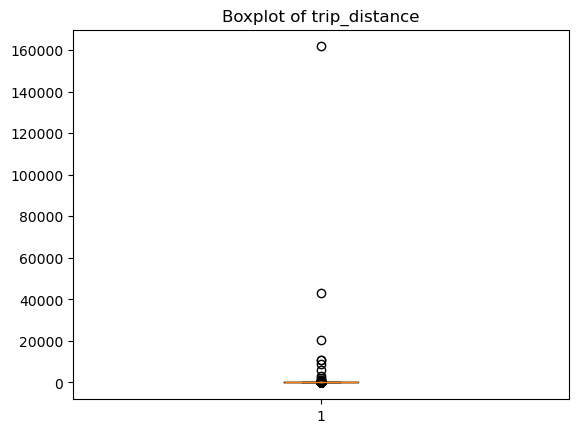

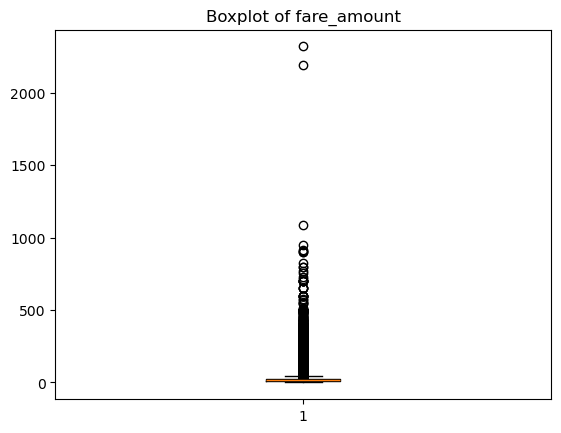

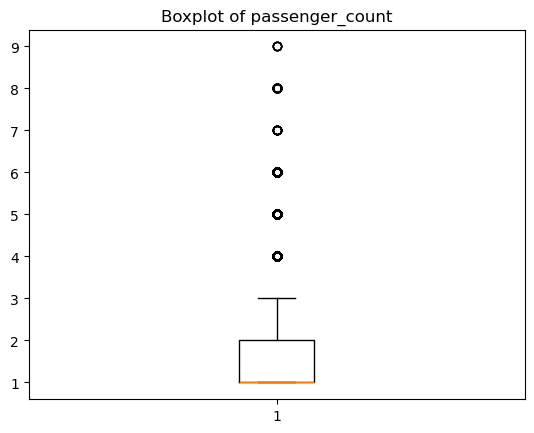

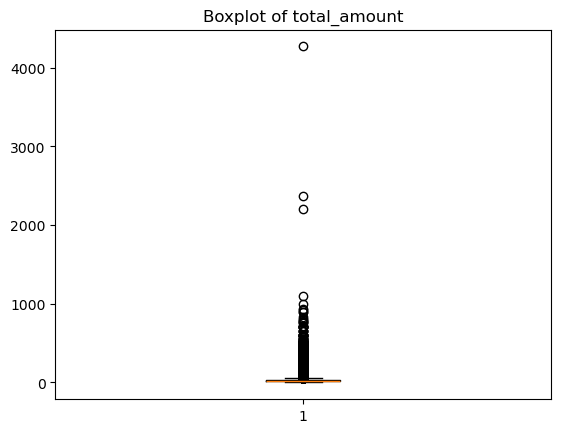

In [37]:
#Boxplots (BEST WAY to See Outliers)
import matplotlib.pyplot as plt

cols = ['trip_distance', 'fare_amount', 'passenger_count', 'total_amount']

for col in cols:
    plt.figure()
    plt.boxplot(df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [38]:
#Check Logical Errors
# Unrealistic values
print("Trips > 100 miles:", (df['trip_distance'] > 100).sum())
print("Fare > 500:", (df['fare_amount'] > 500).sum())
print("Passengers > 6:", (df['passenger_count'] > 6).sum())

Trips > 100 miles: 34
Fare > 500: 39
Passengers > 6: 75


**2.3.1**  <font color = red>[10 marks]</font> <br>
Based on the above analysis, it seems that some of the outliers are present due to errors in registering the trips. Fix the outliers.

Some points you can look for:
- Entries where `trip_distance` is nearly 0 and `fare_amount` is more than 300
- Entries where `trip_distance` and `fare_amount` are 0 but the pickup and dropoff zones are different (both distance and fare should not be zero for different zones)
- Entries where `trip_distance` is more than 250  miles.
- Entries where `payment_type` is 0 (there is no payment_type 0 defined in the data dictionary)

These are just some suggestions. You can handle outliers in any way you wish, using the insights from above outlier analysis.

How will you fix each of these values? Which ones will you drop and which ones will you replace?

First, let us remove 7+ passenger counts as there are very less instances.

In [39]:
# remove passenger_count > 6
# Remove invalid passenger counts
df = df[df['passenger_count'] <= 6]

print("Shape after removing passenger_count > 6:", df.shape)

Shape after removing passenger_count > 6: (3156667, 19)


In [40]:
# Continue with outlier handling
#Define IQR Function
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

In [41]:
#Apply IQR on Important Columns
cols = ['trip_distance', 'fare_amount', 'total_amount']

for col in cols:
    before = df.shape[0]
    df = remove_outliers_iqr(df, col)
    after = df.shape[0]
    
    print(f"{col}: Removed {before - after} outliers")

trip_distance: Removed 410350 outliers
fare_amount: Removed 73914 outliers
total_amount: Removed 43036 outliers


In [42]:
#Final Shape After Outlier Removal
print("Final dataset shape:", df.shape)

Final dataset shape: (2629367, 19)


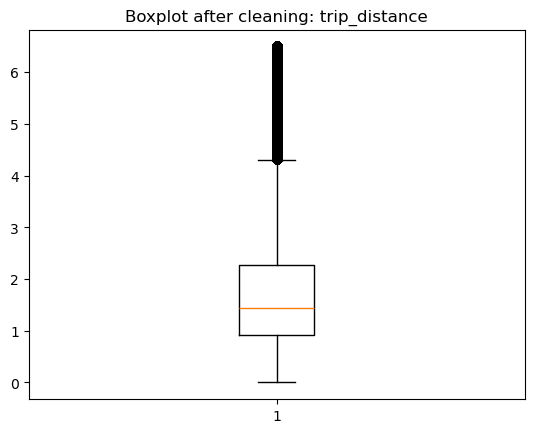

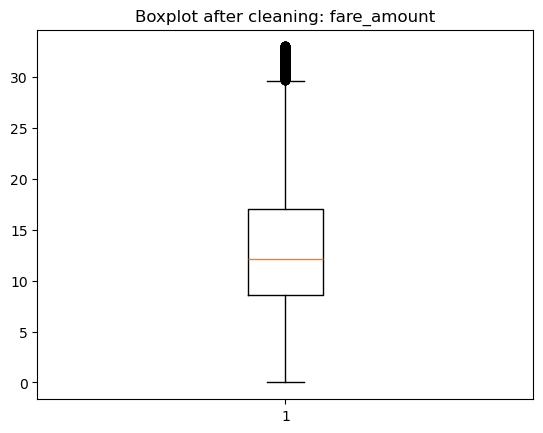

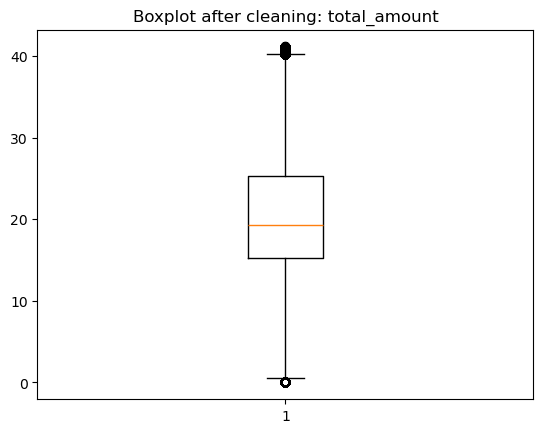

In [43]:
#Visual Check Again
import matplotlib.pyplot as plt

cols = ['trip_distance', 'fare_amount', 'total_amount']

for col in cols:
    plt.figure()
    plt.boxplot(df[col])
    plt.title(f'Boxplot after cleaning: {col}')
    plt.show()

In [44]:
# Do any columns need standardising?
#no need


## **3** Exploratory Data Analysis
<font color = red>[90 marks]</font> <br>

In [45]:
df.columns.tolist()

['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'store_and_fwd_flag',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'airport_fee_combined']

#### **3.1** General EDA: Finding Patterns and Trends
<font color = red>[40 marks]</font> <br>

**3.1.1** <font color = red>[3 marks]</font> <br>
Categorise the varaibles into Numerical or Categorical.
* `VendorID`: Categorical Represents vendor labels (1,2)
* `tpep_pickup_datetime`:Categorical(Temporal) Time-based, not numeric magnitude
* `tpep_dropoff_datetime`:Categorical(Temporal) Time-based, not numeric magnitude
* `passenger_count`:: Numerical (Discrete) Count variable
* `trip_distance`:Numerical (Continuous) Measured distance
* `RatecodeID`:Categorical Encoded categories (1–6)
* `PULocationID`:Categorical Location identifier
* `DOLocationID`:Categorical Location identifier
* `payment_type`:Categorical Encoded payment categories
* `pickup_hour`:Categorical (Ordinal) Time bucket (0–23)
* `trip_duration`:Numerical (Continuous) Time measurement


The following monetary parameters belong in the same category, is it categorical or numerical?


* `fare_amount`Categorical
* `extra`Categorical
* `mta_tax`Categorical
* `tip_amount`Categorical
* `tolls_amount`Categorical
* `improvement_surcharge`Categorical
* `total_amount`Categorical
* `congestion_surcharge`Categorical
* `airport_fee`Categorical

##### Temporal Analysis

**3.1.2** <font color = red>[5 marks]</font> <br>
Analyse the distribution of taxi pickups by hours, days of the week, and months.

In [46]:
# Find and show the hourly trends in taxi pickups



In [47]:
#Hourly Trends in Taxi Pickups

# Extract pickup hour (if not already created)
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour

# Count trips per hour
hourly_trips = df.groupby('pickup_hour').size()

hourly_trips

pickup_hour
0      80078
1      55466
2      36959
3      23029
4      12634
5       9994
6      26369
7      61667
8      89929
9     108163
10    124122
11    137797
12    150795
13    152719
14    159111
15    167029
16    160328
17    173535
18    184092
19    166415
20    150955
21    151071
22    137824
23    109286
dtype: int64

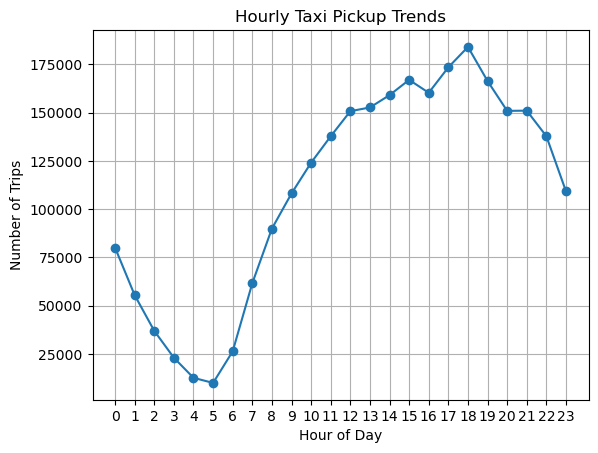

In [48]:
#plot Hourly Trend
import matplotlib.pyplot as plt

plt.figure()
hourly_trips.plot(kind='line', marker='o')

plt.title("Hourly Taxi Pickup Trends")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")

plt.xticks(range(0, 24))
plt.grid()

plt.show()

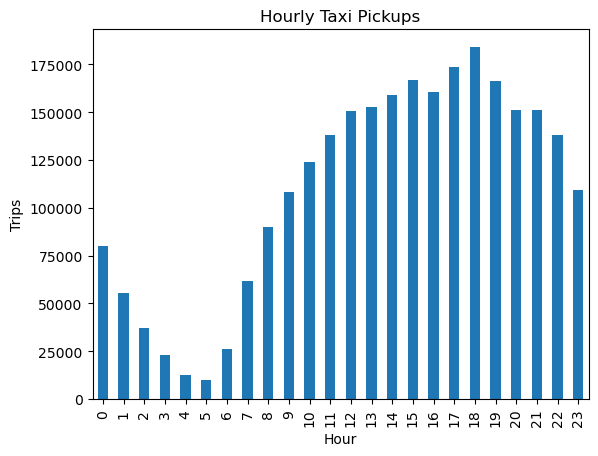

In [49]:
#bar chart
plt.figure()
hourly_trips.plot(kind='bar')

plt.title("Hourly Taxi Pickups")
plt.xlabel("Hour")
plt.ylabel("Trips")

plt.show()

In [50]:
# Find and show the daily trends in taxi pickups (days of the week)

#Daily Trends (Day of Week)

# Extract weekday (0 = Monday, 6 = Sunday)
df['pickup_weekday'] = df['tpep_pickup_datetime'].dt.dayofweek

# Map to day names
day_map = {
    0: 'Mon', 1: 'Tue', 2: 'Wed',
    3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'
}

df['pickup_day_name'] = df['pickup_weekday'].map(day_map)

# Count trips per day
daily_trips = df.groupby('pickup_day_name').size()

# Sort properly
daily_trips = daily_trips.reindex(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])

daily_trips

pickup_day_name
Mon    278682
Tue    344654
Wed    365444
Thu    372148
Fri    465352
Sat    443433
Sun    359654
dtype: int64

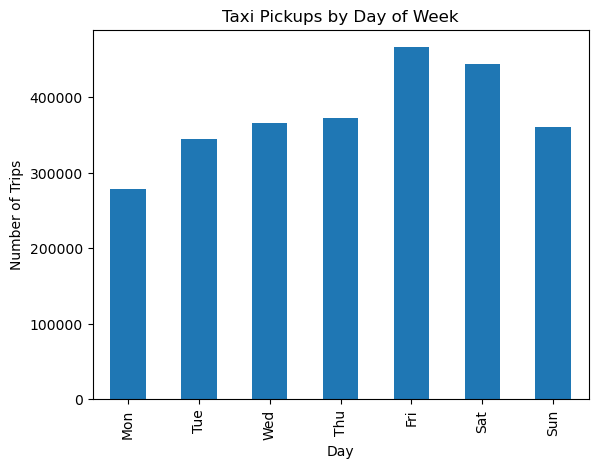

In [51]:
#Plot Daily Trends
import matplotlib.pyplot as plt

plt.figure()
daily_trips.plot(kind='bar')

plt.title("Taxi Pickups by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Trips")

plt.show()

In [52]:
# Show the monthly trends in pickups
# Extract month
df['pickup_month'] = df['tpep_pickup_datetime'].dt.month

# Map month names
month_map = {
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr',
    5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug',
    9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
}

df['pickup_month_name'] = df['pickup_month'].map(month_map)

# Count trips per month
monthly_trips = df.groupby('pickup_month_name').size()

# Sort correctly
monthly_trips = monthly_trips.reindex([
    'Jan','Feb','Mar','Apr','May','Jun',
    'Jul','Aug','Sep','Oct','Nov','Dec'
])

monthly_trips


pickup_month_name
Jan          3.0
Feb          NaN
Mar          NaN
Apr          NaN
May          NaN
Jun          NaN
Jul          NaN
Aug          NaN
Sep          NaN
Oct          NaN
Nov         28.0
Dec    2629336.0
dtype: float64

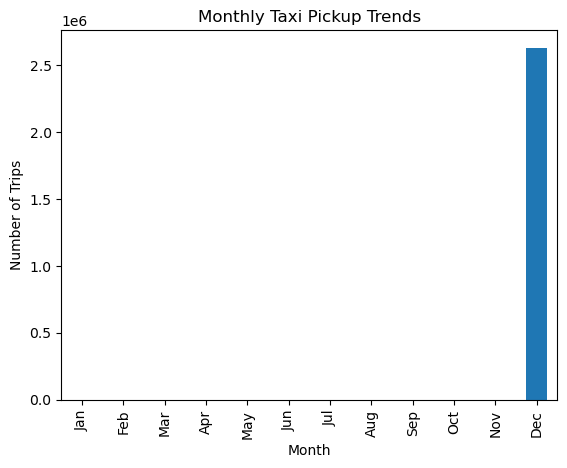

In [53]:
#Plot Monthly Trends
import matplotlib.pyplot as plt

plt.figure()
monthly_trips.plot(kind='bar')

plt.title("Monthly Taxi Pickup Trends")
plt.xlabel("Month")
plt.ylabel("Number of Trips")

plt.show()

##### Financial Analysis

Take a look at the financial parameters like `fare_amount`, `tip_amount`, `total_amount`, and also `trip_distance`. Do these contain zero/negative values?

In [54]:
# Analyse the above parameters
#Check Zero & Negative Values

cols = ['fare_amount', 'tip_amount', 'total_amount', 'trip_distance']

for col in cols:
    print(f"\nColumn: {col}")
    print("Negative values:", (df[col] < 0).sum())
    print("Zero values:", (df[col] == 0).sum())


Column: fare_amount
Negative values: 0
Zero values: 749

Column: tip_amount
Negative values: 0
Zero values: 579991

Column: total_amount
Negative values: 0
Zero values: 441

Column: trip_distance
Negative values: 0
Zero values: 25370


In [55]:
#Fix the Issues
# Remove invalid records
df = df[
    (df['fare_amount'] > 0) &
    (df['total_amount'] > 0) &
    (df['trip_distance'] > 0)
]

print("Shape after financial cleaning:", df.shape)

Shape after financial cleaning: (2603669, 24)


In [56]:
#SPECIAL CASE — tip_amount
df['tip_amount'] == 0  # valid

0          False
1          False
2          False
3           True
4          False
           ...  
3196558    False
3196559    False
3196560    False
3196561    False
3196562    False
Name: tip_amount, Length: 2603669, dtype: bool

Do you think it is beneficial to create a copy DataFrame leaving out the zero values from these?

Yes — but do it smartly, not blindly.
It’s useful when:You want clean analysis without noise.You don’t want to lose original data. You want to compare before vs after cleaning
Especially for:
fare_amount
total_amount
trip_distance

**3.1.3** <font color = red>[2 marks]</font> <br>
Filter out the zero values from the above columns.

**Note:** The distance might be 0 in cases where pickup and drop is in the same zone. Do you think it is suitable to drop such cases of zero distance?

Trip distance can be zero in cases where pickup and drop-off locations are the same zone. These trips may still have a valid fare due to minimum charges. Hence, it is not always appropriate to remove zero-distance trips blindly.For financial and distance-based analysis, zero-distance trips can distort results, so we create a filtered dataset excluding such values.

In [57]:
# Create a df with non zero entries for the selected parameters.

df_filtered = df[
    (df['fare_amount'] > 0) &
    (df['total_amount'] > 0) &
    (df['tip_amount'] >= 0) &   # tip can be zero
    (df['trip_distance'] > 0)   # exclude zero distance for analysis
].copy()

print("Original shape:", df.shape)
print("Filtered shape:", df_filtered.shape)

Original shape: (2603669, 24)
Filtered shape: (2603669, 24)


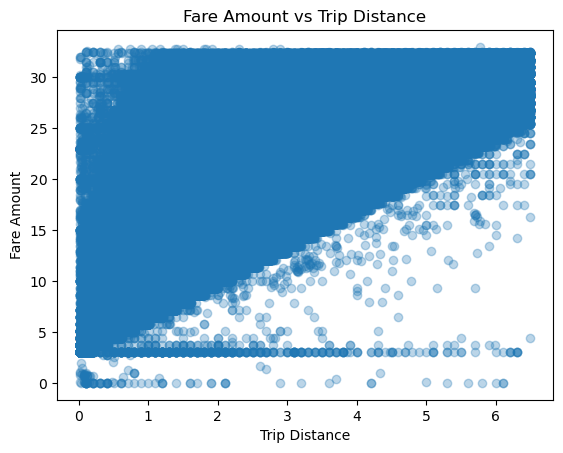

In [58]:
#Scatter Plot: Fare vs Distance
import matplotlib.pyplot as plt

plt.figure()

plt.scatter(
    df_filtered['trip_distance'],
    df_filtered['fare_amount'],
    alpha=0.3
)

plt.title("Fare Amount vs Trip Distance")
plt.xlabel("Trip Distance")
plt.ylabel("Fare Amount")

plt.show()

**3.1.4** <font color = red>[3 marks]</font> <br>
Analyse the monthly revenue (`total_amount`) trend

In [59]:
# Group data by month and analyse monthly revenue


#Monthly Revenue Calculation


# Extract month if not already done
df_filtered['pickup_month'] = df_filtered['tpep_pickup_datetime'].dt.month

# Map month names
month_map = {
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr',
    5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug',
    9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
}

df_filtered['month_name'] = df_filtered['pickup_month'].map(month_map)

# Group by month and sum revenue
monthly_revenue = df_filtered.groupby('month_name')['total_amount'].sum()

# Sort correctly
monthly_revenue = monthly_revenue.reindex([
    'Jan','Feb','Mar','Apr','May','Jun',
    'Jul','Aug','Sep','Oct','Nov','Dec'
])

monthly_revenue

month_name
Jan          45.73
Feb            NaN
Mar            NaN
Apr            NaN
May            NaN
Jun            NaN
Jul            NaN
Aug            NaN
Sep            NaN
Oct            NaN
Nov         541.21
Dec    54315803.42
Name: total_amount, dtype: float64

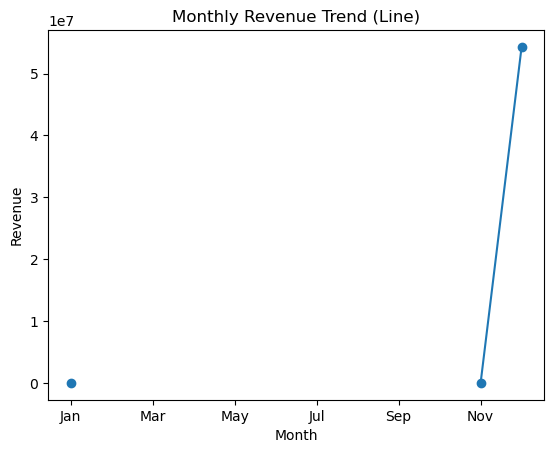

In [60]:
#Line Plot for Trend Clarity
plt.figure()

monthly_revenue.plot(marker='o')

plt.title("Monthly Revenue Trend (Line)")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

**3.1.5** <font color = red>[3 marks]</font> <br>
Show the proportion of each quarter of the year in the revenue

In [61]:
#Extract Quarter
# Create quarter column
df_filtered['quarter'] = df_filtered['tpep_pickup_datetime'].dt.to_period('Q')


In [62]:
#Revenue per Quarter
# Total revenue per quarter
quarter_revenue = df_filtered.groupby('quarter')['total_amount'].sum()

quarter_revenue

quarter
2002Q4          21.78
2009Q1          16.17
2023Q4    54316322.85
2024Q1          29.56
Freq: Q-DEC, Name: total_amount, dtype: float64

In [63]:
#Proportion of Each Quarter
# Proportion
quarter_proportion = quarter_revenue / quarter_revenue.sum()

quarter_proportion


quarter
2002Q4    4.009839e-07
2009Q1    2.977002e-07
2023Q4    9.999988e-01
2024Q1    5.442188e-07
Freq: Q-DEC, Name: total_amount, dtype: float64

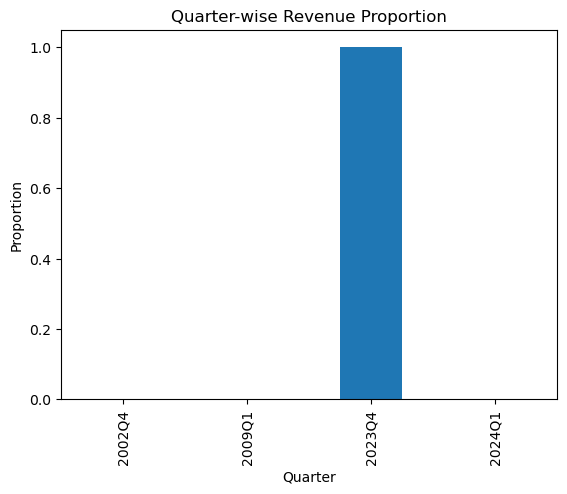

In [64]:
#Plot
import matplotlib.pyplot as plt

plt.figure()

quarter_proportion.plot(kind='bar')

plt.title("Quarter-wise Revenue Proportion")
plt.xlabel("Quarter")
plt.ylabel("Proportion")

plt.show()

In [65]:
# Calculate proportion of each quarter
#Create Quarter Column
# Create quarter column
df_filtered['quarter'] = df_filtered['tpep_pickup_datetime'].dt.to_period('Q')

df_filtered[['tpep_pickup_datetime', 'quarter']].head()

,tpep_pickup_datetime,quarter
0,2023-12-01 00:06:06,2023Q4
1,2023-12-01 00:22:26,2023Q4
2,2023-12-01 00:59:44,2023Q4
3,2023-12-01 00:22:17,2023Q4
4,2023-12-01 00:18:16,2023Q4


In [66]:
#Calculate Revenue per Quarter
quarter_revenue = df_filtered.groupby('quarter')['total_amount'].sum()

quarter_revenue

quarter
2002Q4          21.78
2009Q1          16.17
2023Q4    54316322.85
2024Q1          29.56
Freq: Q-DEC, Name: total_amount, dtype: float64

In [67]:
#Calculate Proportion of Each Quarter
quarter_proportion = quarter_revenue / quarter_revenue.sum()

quarter_proportion


quarter
2002Q4    4.009839e-07
2009Q1    2.977002e-07
2023Q4    9.999988e-01
2024Q1    5.442188e-07
Freq: Q-DEC, Name: total_amount, dtype: float64

In [68]:
#Percentage Format
(quarter_proportion * 100).round(2)

quarter
2002Q4      0.0
2009Q1      0.0
2023Q4    100.0
2024Q1      0.0
Freq: Q-DEC, Name: total_amount, dtype: float64

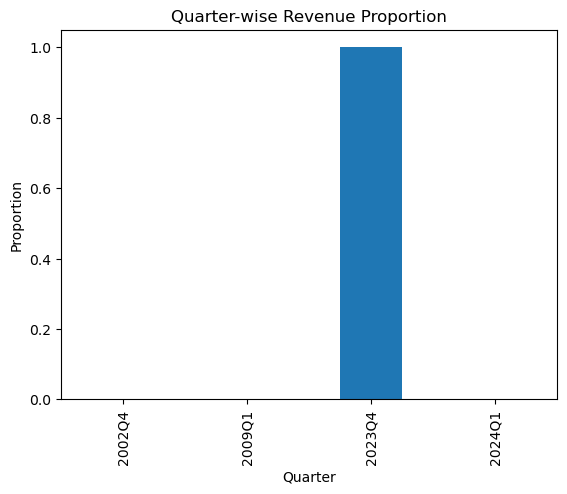

In [69]:
#Plot Quarter-wise Contribution
import matplotlib.pyplot as plt

plt.figure()

quarter_proportion.plot(kind='bar')

plt.title("Quarter-wise Revenue Proportion")
plt.xlabel("Quarter")
plt.ylabel("Proportion")

plt.show()

**3.1.6** <font color = red>[3 marks]</font> <br>
Visualise the relationship between `trip_distance` and `fare_amount`. Also find the correlation value for these two.

**Hint:** You can leave out the trips with trip_distance = 0

In [70]:
# Show how trip fare is affected by distance
#Filter (remove zero distance)
# Remove zero distance trips
df_plot = df_filtered[df_filtered['trip_distance'] > 0]

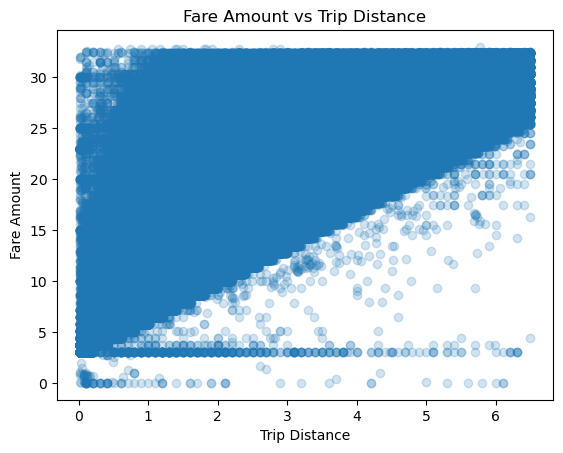

In [71]:
#Scatter Plot (Relationship)
import matplotlib.pyplot as plt

plt.figure()

plt.scatter(
    df_plot['trip_distance'],
    df_plot['fare_amount'],
    alpha=0.2
)

plt.title("Fare Amount vs Trip Distance")
plt.xlabel("Trip Distance")
plt.ylabel("Fare Amount")

plt.show()

In [72]:
#Correlation Value
correlation = df_plot[['trip_distance', 'fare_amount']].corr()

correlation

,trip_distance,fare_amount
trip_distance,1.000000,0.825976
fare_amount,0.825976,1.000000


**3.1.7** <font color = red>[5 marks]</font> <br>
Find and visualise the correlation between:
1. `fare_amount` and trip duration (pickup time to dropoff time)
2. `fare_amount` and `passenger_count`
3. `tip_amount` and `trip_distance`

In [73]:
# Show relationship between fare and trip duration

# Create trip duration in minutes
df_filtered['trip_duration'] = (
    (df_filtered['tpep_dropoff_datetime'] - df_filtered['tpep_pickup_datetime'])
    .dt.total_seconds() / 60
)

In [74]:
# Remove zero or negative duration
df_duration = df_filtered[df_filtered['trip_duration'] > 0]

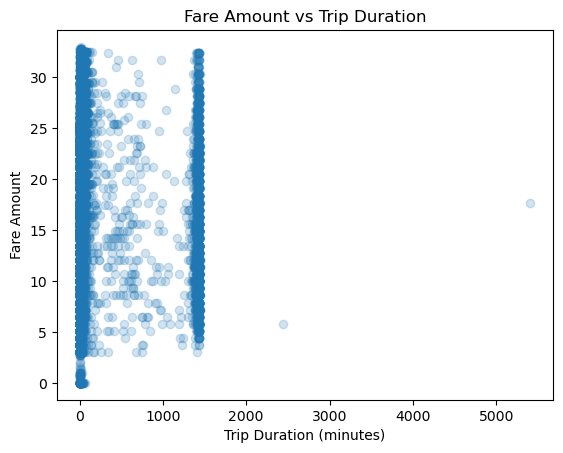

In [75]:
#Scatter Plot (Fare vs Duration)
import matplotlib.pyplot as plt

plt.figure()

plt.scatter(
    df_duration['trip_duration'],
    df_duration['fare_amount'],
    alpha=0.2
)

plt.title("Fare Amount vs Trip Duration")
plt.xlabel("Trip Duration (minutes)")
plt.ylabel("Fare Amount")

plt.show()

In [76]:
#Correlation
df_duration['trip_duration'].corr(df_duration['fare_amount'])

0.1952951523470867

<Figure size 640x480 with 0 Axes>

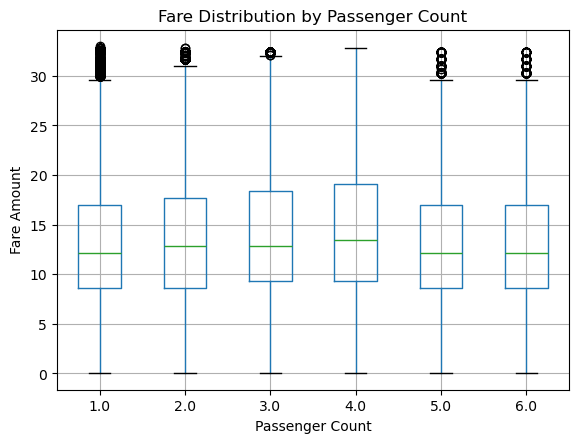

In [77]:
# Show relationship between fare and number of passengers 
#Boxplot  (Fare vs Passenger Count)
plt.figure()

df_filtered.boxplot(column='fare_amount', by='passenger_count')

plt.title("Fare Distribution by Passenger Count")
plt.suptitle("")  # removes extra title
plt.xlabel("Passenger Count")
plt.ylabel("Fare Amount")

plt.show()

In [78]:
#Average Fare by Passenger Count
df_filtered.groupby('passenger_count')['fare_amount'].mean()

passenger_count
1.0    13.353267
2.0    13.791748
3.0    14.118673
4.0    14.658241
5.0    13.489951
6.0    13.488464
Name: fare_amount, dtype: float64

In [79]:
#CORRELATION
df_filtered['passenger_count'].corr(df_filtered['fare_amount'])

0.03542591967891425

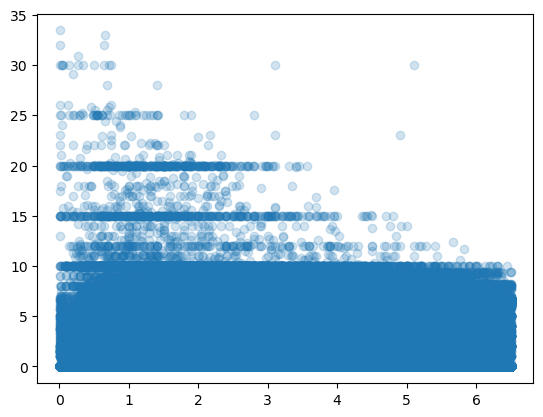

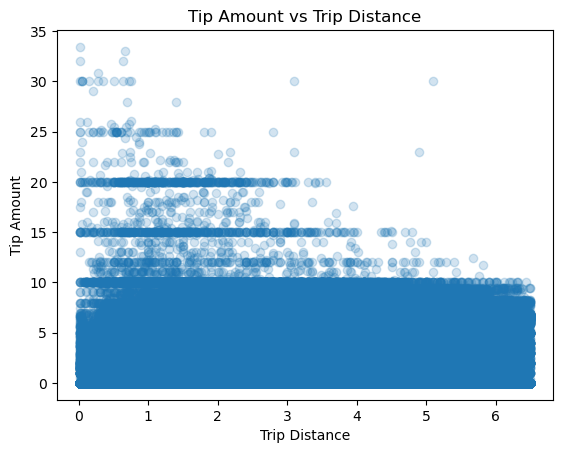

In [80]:
# Show relationship between tip and trip distance


#Filter Valid Data
df_tip = df[['trip_distance', 'tip_amount']].dropna()

#Scatter Plot (Tip vs Distance)
plt.scatter(df_tip['trip_distance'], df_tip['tip_amount'], alpha=0.2)

import matplotlib.pyplot as plt

plt.figure()

plt.scatter(
    df_tip['trip_distance'],
    df_tip['tip_amount'],
    alpha=0.2
)

plt.title("Tip Amount vs Trip Distance")
plt.xlabel("Trip Distance")
plt.ylabel("Tip Amount")

plt.show()

In [81]:
#Average Tip by Distance Buckets
df_tip['distance_bin'] = pd.cut(df_tip['trip_distance'], bins=5)

df_tip.groupby('distance_bin')['tip_amount'].mean()

C:\Users\mohit\AppData\Local\Temp\ipykernel_25900\2387022011.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_tip.groupby('distance_bin')['tip_amount'].mean()


distance_bin
(0.00351, 1.308]    2.015032
(1.308, 2.606]      2.874004
(2.606, 3.904]      3.653346
(3.904, 5.202]      3.928522
(5.202, 6.5]        3.495367
Name: tip_amount, dtype: float64

In [82]:
#CORREALTION
df_tip['trip_distance'].corr(df_tip['tip_amount'])

0.32254145900975006

**3.1.8** <font color = red>[3 marks]</font> <br>
Analyse the distribution of different payment types (`payment_type`)

In [83]:
# Analyse the distribution of different payment types (payment_type).

#Payment Type Distribution (Counts)
payment_counts = df_filtered['payment_type'].value_counts()

payment_counts

payment_type
1    2126626
2     444617
4      21707
3      10719
Name: count, dtype: int64

In [84]:
#Convert to Percentage
payment_percentage = df_filtered['payment_type'].value_counts(normalize=True) * 100

payment_percentage

payment_type
1    81.678047
2    17.076556
4     0.833708
3     0.411688
Name: proportion, dtype: float64

In [85]:
#Map Payment Type Labels
payment_map = {
    1: 'Credit Card',
    2: 'Cash',
    3: 'No Charge',
    4: 'Dispute',
    5: 'Unknown',
    6: 'Voided Trip'
}

df_filtered['payment_type_name'] = df_filtered['payment_type'].map(payment_map)

df_filtered[['payment_type', 'payment_type_name']].head()

,payment_type,payment_type_name
0,1,Credit Card
1,1,Credit Card
2,1,Credit Card
3,2,Cash
4,1,Credit Card


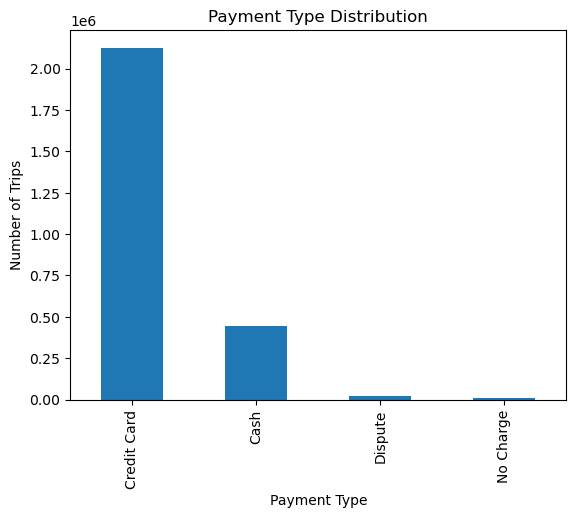

In [86]:

#Plot Distribution
import matplotlib.pyplot as plt

payment_counts_named = df_filtered['payment_type_name'].value_counts()

plt.figure()

payment_counts_named.plot(kind='bar')

plt.title("Payment Type Distribution")
plt.xlabel("Payment Type")
plt.ylabel("Number of Trips")

plt.show()

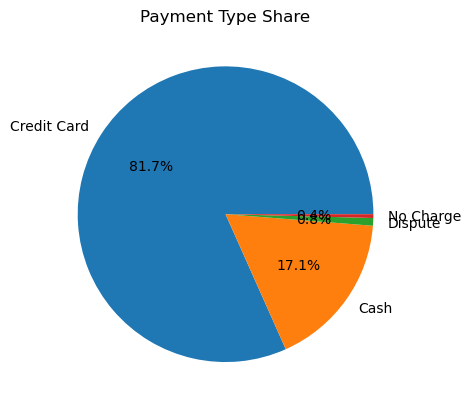

In [87]:
#Pie Chart
plt.figure()

payment_counts_named.plot(kind='pie', autopct='%1.1f%%')

plt.title("Payment Type Share")

plt.ylabel("")
plt.show()

- 1= Credit card
- 2= Cash
- 3= No charge
- 4= Dispute



##### Geographical Analysis

For this, you have to use the *taxi_zones.shp* file from the *taxi_zones* folder.

There would be multiple files inside the folder (such as *.shx, .sbx, .sbn* etc). You do not need to import/read any of the files other than the shapefile, *taxi_zones.shp*.

Do not change any folder structure - all the files need to be present inside the folder for it to work.

The folder structure should look like this:
```
Taxi Zones
|- taxi_zones.shp.xml
|- taxi_zones.prj
|- taxi_zones.sbn
|- taxi_zones.shp
|- taxi_zones.dbf
|- taxi_zones.shx
|- taxi_zones.sbx

 ```

 You only need to read the `taxi_zones.shp` file. The *shp* file will utilise the other files by itself.

We will use the *GeoPandas* library for geopgraphical analysis
```
import geopandas as gpd
```

More about geopandas and shapefiles: [About](https://geopandas.org/en/stable/about.html)


Reading the shapefile is very similar to *Pandas*. Use `gpd.read_file()` function to load the data (*taxi_zones.shp*) as a GeoDataFrame. Documentation: [Reading and Writing Files](https://geopandas.org/en/stable/docs/user_guide/io.html)

In [88]:
!pip install geopandas

**3.1.9** <font color = red>[2 marks]</font> <br>
Load the shapefile and display it.

In [89]:
#Read Shapefile using GeoPandas
import geopandas as gpd

# Read shapefile
zones = gpd.read_file("taxi_zones.shp")

zones.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


In [90]:
#Verify Loaded Data
zones.info()
#Check Columns (Important for mapping later)
zones.columns


<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID    263 non-null    int32   
 1   Shape_Leng  263 non-null    float64 
 2   Shape_Area  263 non-null    float64 
 3   zone        263 non-null    object  
 4   LocationID  263 non-null    int32   
 5   borough     263 non-null    object  
 6   geometry    263 non-null    geometry
dtypes: float64(2), geometry(1), int32(2), object(2)
memory usage: 12.5+ KB


Index(['OBJECTID', 'Shape_Leng', 'Shape_Area', 'zone', 'LocationID', 'borough',
       'geometry'],
      dtype='object')

Now, if you look at the DataFrame created, you will see columns like: `OBJECTID`,`Shape_Leng`, `Shape_Area`, `zone`, `LocationID`, `borough`, `geometry`.
<br><br>

Now, the `locationID` here is also what we are using to mark pickup and drop zones in the trip records.

The geometric parameters like shape length, shape area and geometry are used to plot the zones on a map.

This can be easily done using the `plot()` method.

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID    263 non-null    int32   
 1   Shape_Leng  263 non-null    float64 
 2   Shape_Area  263 non-null    float64 
 3   zone        263 non-null    object  
 4   LocationID  263 non-null    int32   
 5   borough     263 non-null    object  
 6   geometry    263 non-null    geometry
dtypes: float64(2), geometry(1), int32(2), object(2)
memory usage: 12.5+ KB
None


<Axes: >

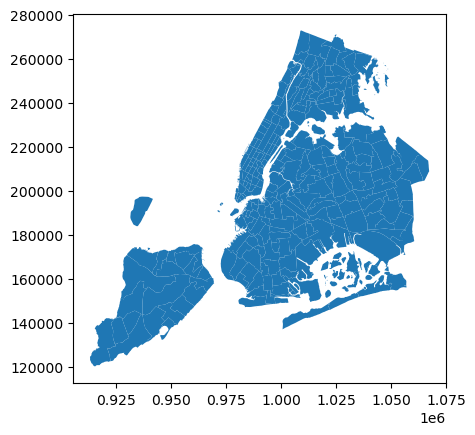

In [91]:
print(zones.info())

zones.plot()

Now, you have to merge the trip records and zones data using the location IDs.



**3.1.10** <font color = red>[3 marks]</font> <br>
Merge the zones data into trip data using the `locationID` and `PULocationID` columns.

In [92]:
# Merge zones and trip records using locationID and PULocationID
# Merge pickup location info
df_geo = df_filtered.merge(
    zones[['LocationID', 'zone', 'borough']],
    left_on='PULocationID',
    right_on='LocationID',
    how='left'
)

df_geo.head()





,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,pickup_day_name,pickup_month,pickup_month_name,month_name,quarter,trip_duration,payment_type_name,LocationID,zone,borough
0,1,2023-12-01 00:06:06,2023-12-01 00:15:47,1.0,1.10,1.0,N,230,48,1,...,Fri,12,Dec,Dec,2023Q4,9.683333,Credit Card,230.0,Times Sq/Theatre District,Manhattan
1,1,2023-12-01 00:22:26,2023-12-01 00:28:53,1.0,1.50,1.0,N,142,238,1,...,Fri,12,Dec,Dec,2023Q4,6.450000,Credit Card,142.0,Lincoln Square East,Manhattan
2,1,2023-12-01 00:59:44,2023-12-01 01:13:22,2.0,2.20,1.0,N,114,186,1,...,Fri,12,Dec,Dec,2023Q4,13.633333,Credit Card,114.0,Greenwich Village South,Manhattan
3,2,2023-12-01 00:22:17,2023-12-01 00:30:59,1.0,0.66,1.0,N,79,79,2,...,Fri,12,Dec,Dec,2023Q4,8.700000,Cash,79.0,East Village,Manhattan
4,2,2023-12-01 00:18:16,2023-12-01 00:25:32,2.0,2.20,1.0,N,229,263,1,...,Fri,12,Dec,Dec,2023Q4,7.266667,Credit Card,229.0,Sutton Place/Turtle Bay North,Manhattan


In [93]:
# Verify Merge
df_geo[['PULocationID', 'zone', 'borough']].head()

,PULocationID,zone,borough
0,230,Times Sq/Theatre District,Manhattan
1,142,Lincoln Square East,Manhattan
2,114,Greenwich Village South,Manhattan
3,79,East Village,Manhattan
4,229,Sutton Place/Turtle Bay North,Manhattan


In [94]:
#Check Missing Matches
df_geo['zone'].isnull().sum()

10187

**3.1.11** <font color = red>[3 marks]</font> <br>
Group data by location IDs to find the total number of trips per location ID

In [101]:
#Trips per Location ID
# Count trips per pickup location
location_trips = df_filtered.groupby('PULocationID').size().reset_index(name='trip_count')

location_trips.head()

,PULocationID,trip_count
0,1,16
1,3,28
2,4,3049
3,6,7
4,7,1012


In [102]:
#(Top Busy Locations)
# Sort by trip count
top_locations = location_trips.sort_values(by='trip_count', ascending=False)

top_locations.head(10)


,PULocationID,trip_count
215,237,149462
214,236,133002
145,161,124542
127,142,105625
146,162,105008
168,186,96025
208,230,87463
147,163,86424
217,239,85885
154,170,81935


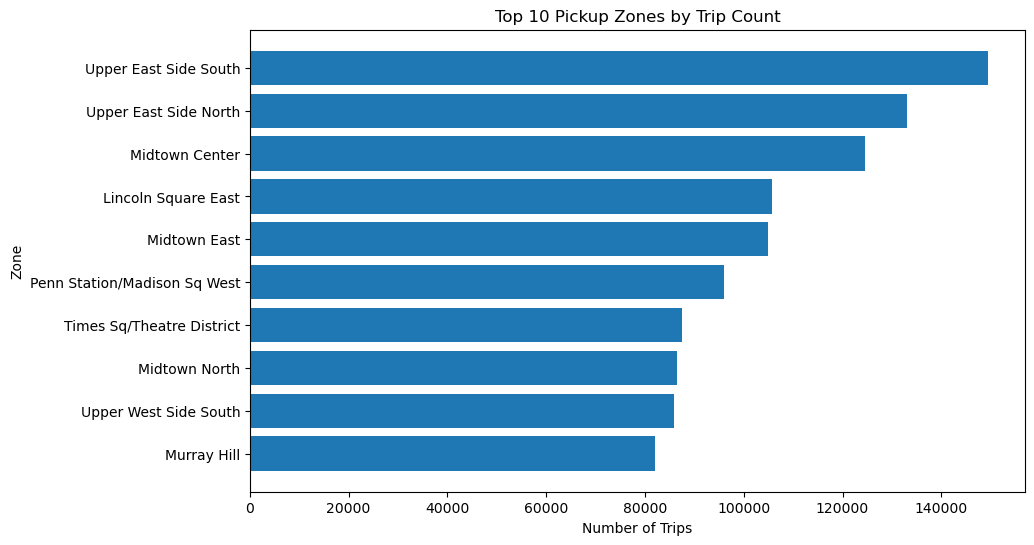

In [105]:
# Group by zone and count trips
location_trips_named = df_geo.groupby('zone').size().reset_index(name='trip_count')

# Sort by highest trips and take top 10
top10 = location_trips_named.sort_values(by='trip_count', ascending=False).head(10)

# Plot top 10 zones
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.barh(top10['zone'], top10['trip_count'])
plt.xlabel("Number of Trips")
plt.ylabel("Zone")
plt.title("Top 10 Pickup Zones by Trip Count")
plt.gca().invert_yaxis()  # largest bar at the top
plt.show()


**3.1.12** <font color = red>[2 marks]</font> <br>
Now, use the grouped data to add number of trips to the GeoDataFrame.

We will use this to plot a map of zones showing total trips per zone.

In [106]:
#Merge Trip Counts with Zones
# Merge trip counts back to the zones GeoDataFrame
zones_trips = zones.merge(
    location_trips,
    left_on="LocationID",
    right_on="PULocationID",
    how="left"
)







In [107]:
#Handle Missing Values
zones_trips['trip_count'] = zones_trips['trip_count'].fillna(0)

In [108]:
#Verify Merge
zones_trips[['LocationID', 'zone', 'trip_count']].head()

,LocationID,zone,trip_count
0,1,Newark Airport,16.0
1,2,Jamaica Bay,0.0
2,3,Allerton/Pelham Gardens,28.0
3,4,Alphabet City,3049.0
4,5,Arden Heights,0.0


The next step is creating a color map (choropleth map) showing zones by the number of trips taken.

Again, you can use the `zones.plot()` method for this. [Plot Method GPD](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html#geopandas.GeoDataFrame.plot)

But first, you need to define the figure and axis for the plot.

`fig, ax = plt.subplots(1, 1, figsize = (12, 10))`

This function creates a figure (fig) and a single subplot (ax)

---

After setting up the figure and axis, we can proceed to plot the GeoDataFrame on this axis. This is done in the next step where we use the plot method of the GeoDataFrame.

You can define the following parameters in the `zones.plot()` method:
```
column = '',
ax = ax,
legend = True,
legend_kwds = {'label': "label", 'orientation': "<horizontal/vertical>"}
```

To display the plot, use `plt.show()`.

**3.1.13** <font color = red>[3 marks]</font> <br>
Plot a color-coded map showing zone-wise trips

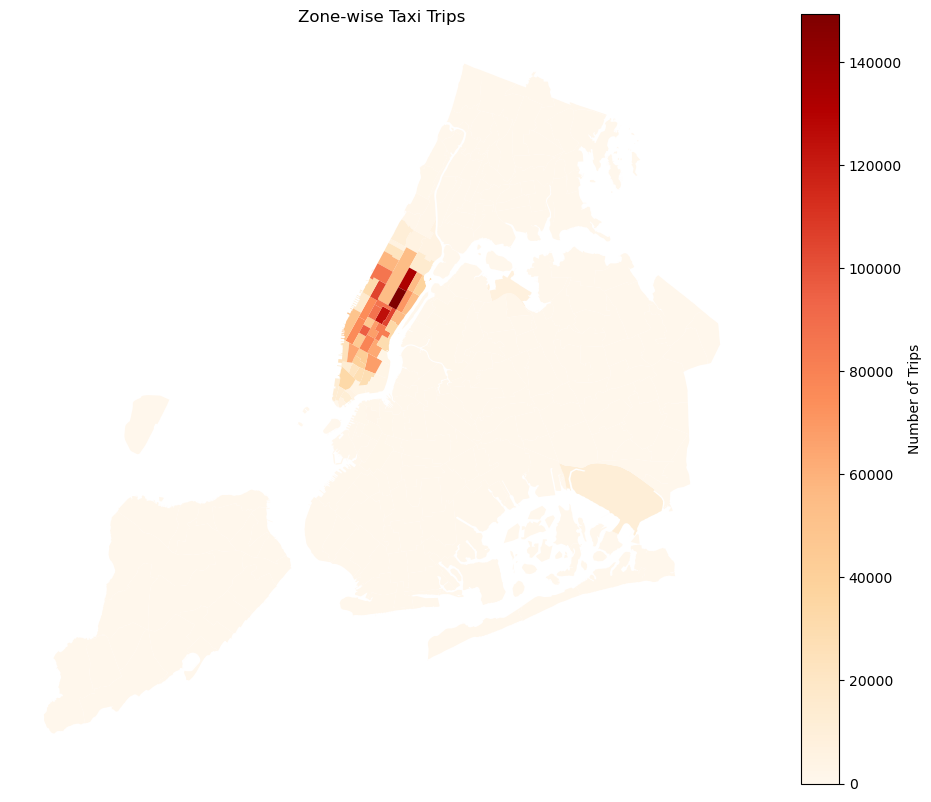

In [109]:
# Define figure and axis
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(12, 10))


# Plot the map and display it
#Plot Choropleth Map
zones_trips.plot(
    column='trip_count',          # color based on trips
    ax=ax,
    legend=True,
    cmap='OrRd',                 # color scheme (Orange-Red)
    legend_kwds={
        'label': "Number of Trips",
        'orientation': "vertical"
    }
)

ax.set_title("Zone-wise Taxi Trips")
ax.axis('off')

plt.show()



In [110]:
# can you try displaying the zones DF sorted by the number of trips?

#Sort Zones by Number of Trips
zones_trips.sort_values(by='trip_count', ascending=False)[
    ['zone', 'borough', 'trip_count']
].head(10)


,zone,borough,trip_count
236,Upper East Side South,Manhattan,149462.0
235,Upper East Side North,Manhattan,133002.0
160,Midtown Center,Manhattan,124542.0
141,Lincoln Square East,Manhattan,105625.0
161,Midtown East,Manhattan,105008.0
185,Penn Station/Madison Sq West,Manhattan,96025.0
229,Times Sq/Theatre District,Manhattan,87463.0
162,Midtown North,Manhattan,86424.0
238,Upper West Side South,Manhattan,85885.0
169,Murray Hill,Manhattan,81935.0


Here we have completed the temporal, financial and geographical analysis on the trip records.

**Compile your findings from general analysis below:**

You can consider the following points:

* Busiest hours, days and months
* Trends in revenue collected
* Trends in quarterly revenue
* How fare depends on trip distance, trip duration and passenger counts
* How tip amount depends on trip distance
* Busiest zones


#### **3.2** Detailed EDA: Insights and Strategies
<font color = red>[50 marks]</font> <br>

Having performed basic analyses for finding trends and patterns, we will now move on to some detailed analysis focussed on operational efficiency, pricing strategies, and customer experience.

##### Operational Efficiency

Analyze variations by time of day and location to identify bottlenecks or inefficiencies in routes

**3.2.1** <font color = red>[3 marks]</font> <br>
Identify slow routes by calculating the average time taken by cabs to get from one zone to another at different hours of the day.

Speed on a route *X* for hour *Y* = (*distance of the route X / average trip duration for hour Y*)

In [111]:
# Find routes which have the slowest speeds at different times of the day

#create trip duration 
# Trip duration in hours
df_filtered['trip_duration_hours'] = (
    (df_filtered['tpep_dropoff_datetime'] - df_filtered['tpep_pickup_datetime'])
    .dt.total_seconds() / 3600
)

# Extract pickup hour
df_filtered['pickup_hour'] = df_filtered['tpep_pickup_datetime'].dt.hour

In [112]:
#Group by Route and Hour
route_speed = df_filtered.groupby(
    ['PULocationID', 'DOLocationID', 'pickup_hour']
).agg({
    'trip_distance': 'mean',
    'trip_duration_hours': 'mean'
}).reset_index()

In [113]:
#calculate speed
# Calculate speed
route_speed['avg_speed'] = (
    route_speed['trip_distance'] /
    route_speed['trip_duration_hours']
)

In [114]:
## Remove unrealistic values
route_speed = route_speed[
    (route_speed['avg_speed'] > 0) &
    (route_speed['avg_speed'] < 100)
]

In [115]:
# Slowest routes
slow_routes = route_speed.sort_values(by='avg_speed')

slow_routes.head(10)

,PULocationID,DOLocationID,pickup_hour,trip_distance,trip_duration_hours,avg_speed
67339,215,132,13,0.07,13.178889,0.005312
69188,226,145,18,0.50,90.183333,0.005544
61104,177,177,19,0.03,4.209444,0.007127
71167,229,264,0,0.24,20.067222,0.011960
68742,224,256,23,0.19,12.468889,0.015238
88823,260,138,20,0.62,40.597500,0.015272
2866,14,172,20,0.32,20.488611,0.015618
2865,14,172,2,0.22,12.390556,0.017755
35384,132,67,23,0.01,0.488056,0.020489
59867,170,129,23,0.06,2.263889,0.026503


In [116]:
# Add pickup zone names
slow_routes = slow_routes.merge(
    zones[['LocationID', 'zone']],
    left_on='PULocationID',
    right_on='LocationID',
    how='left'
)

slow_routes.rename(columns={'zone': 'pickup_zone'}, inplace=True)

# Add dropoff zone names
slow_routes = slow_routes.merge(
    zones[['LocationID', 'zone']],
    left_on='DOLocationID',
    right_on='LocationID',
    how='left'
)

slow_routes.rename(columns={'zone': 'dropoff_zone'}, inplace=True)

In [117]:
slow_routes[[
    'pickup_zone',
    'dropoff_zone',
    'pickup_hour',
    'avg_speed'
]].head(10)

,pickup_zone,dropoff_zone,pickup_hour,avg_speed
0,South Jamaica,JFK Airport,13,0.005312
1,Sunnyside,Long Island City/Hunters Point,18,0.005544
2,Ocean Hill,Ocean Hill,19,0.007127
3,Sutton Place/Turtle Bay North,NaN,0,0.011960
4,Stuy Town/Peter Cooper Village,Williamsburg (South Side),23,0.015238
5,Woodside,LaGuardia Airport,20,0.015272
6,Bay Ridge,New Dorp/Midland Beach,20,0.015618
7,Bay Ridge,New Dorp/Midland Beach,2,0.017755
8,JFK Airport,Dyker Heights,23,0.020489
9,Murray Hill,Jackson Heights,23,0.026503


How does identifying high-traffic, high-demand routes help us?

**3.2.2** <font color = red>[3 marks]</font> <br>
Calculate the number of trips at each hour of the day and visualise them. Find the busiest hour and show the number of trips for that hour.

In [118]:
# Visualise the number of trips per hour and find the busiest hour

# Extract hour from pickup datetime
df_filtered['pickup_hour'] = df_filtered['tpep_pickup_datetime'].dt.hour

In [119]:
# Count trips per hour
hourly_trips = df_filtered.groupby('pickup_hour').size()

hourly_trips

pickup_hour
0      79258
1      54801
2      36412
3      22574
4      12225
5       9693
6      25936
7      61041
8      89115
9     107053
10    122989
11    136511
12    149315
13    151273
14    157477
15    165366
16    158634
17    171960
18    182536
19    164963
20    149699
21    149853
22    136673
23    108312
dtype: int64

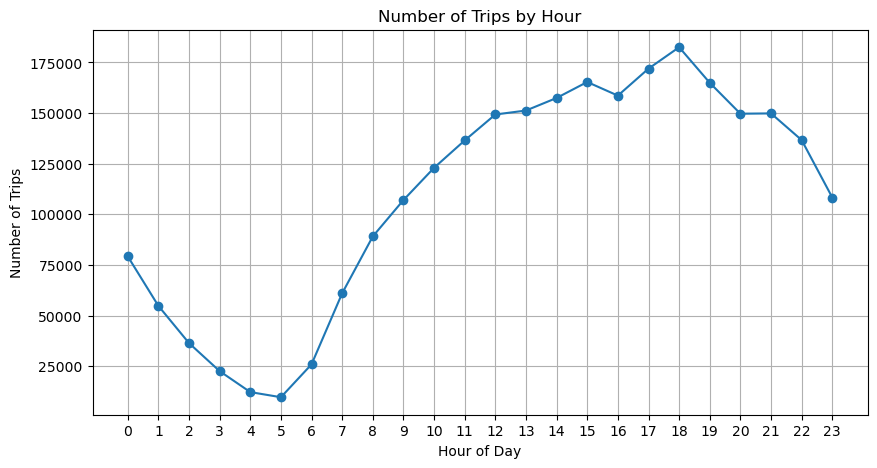

In [120]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

hourly_trips.plot(marker='o')

plt.title("Number of Trips by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")

plt.xticks(range(0,24))
plt.grid()

plt.show()

In [121]:
# Find busiest hour
busiest_hour = hourly_trips.idxmax()
max_trips = hourly_trips.max()

print("Busiest Hour:", busiest_hour)
print("Number of Trips:", max_trips)

Busiest Hour: 18
Number of Trips: 182536


Remember, we took a fraction of trips. To find the actual number, you have to scale the number up by the sampling ratio.

**3.2.3** <font color = red>[2 mark]</font> <br>
Find the actual number of trips in the five busiest hours

In [122]:
# Scale up the number of trips

# Fill in the value of your sampling fraction and use that to scale up the numbers
sample_fraction = 0.05
# Top 5 busiest hours
top5_hours = hourly_trips.sort_values(ascending=False).head(5)

top5_hours



pickup_hour
18    182536
17    171960
15    165366
19    164963
16    158634
dtype: int64

In [123]:
# Estimate actual trips
actual_trips = top5_hours / sample_fraction

actual_trips

pickup_hour
18    3650720.0
17    3439200.0
15    3307320.0
19    3299260.0
16    3172680.0
dtype: float64

In [124]:
comparison = pd.DataFrame({
    'Sampled Trips': top5_hours,
    'Estimated Actual Trips': actual_trips.astype(int)
})

comparison

,Sampled Trips,Estimated Actual Trips
pickup_hour,,
18,182536,3650720
17,171960,3439200
15,165366,3307320
19,164963,3299260
16,158634,3172680


**3.2.4** <font color = red>[3 marks]</font> <br>
Compare hourly traffic pattern on weekdays. Also compare for weekend.

In [125]:
# Compare traffic trends for the week days and weekends
# Extract weekday and hour
df_filtered['pickup_day'] = df_filtered['tpep_pickup_datetime'].dt.day_name()
df_filtered['pickup_hour'] = df_filtered['tpep_pickup_datetime'].dt.hour


In [126]:
# Create day type column
df_filtered['day_type'] = df_filtered['pickup_day'].apply(
    lambda x: 'Weekend' if x in ['Saturday', 'Sunday'] else 'Weekday'
)

In [127]:
traffic_pattern = df_filtered.groupby(
    ['day_type', 'pickup_hour']
).size().reset_index(name='trip_count')

traffic_pattern.head()

,day_type,pickup_hour,trip_count
0,Weekday,0,38387
1,Weekday,1,20371
2,Weekday,2,10840
3,Weekday,3,6368
4,Weekday,4,4322


In [128]:
traffic_pivot = traffic_pattern.pivot(
    index='pickup_hour',
    columns='day_type',
    values='trip_count'
)

traffic_pivot

day_type,Weekday,Weekend
pickup_hour,,
0,38387,40871
1,20371,34430
2,10840,25572
3,6368,16206
4,4322,7903
5,7157,2536
6,21720,4216
7,53193,7848
8,73895,15220


<Figure size 1000x500 with 0 Axes>

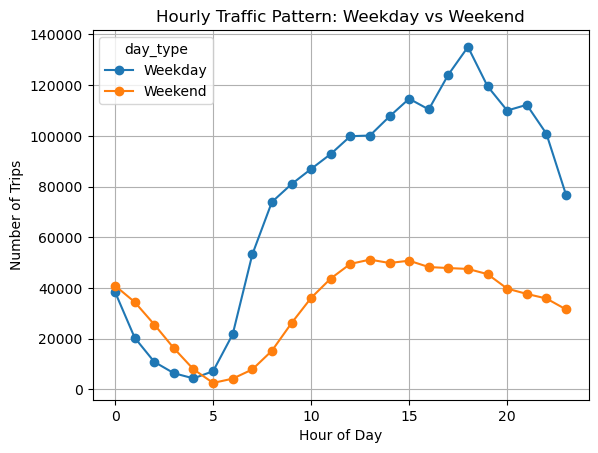

In [129]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

traffic_pivot.plot(marker='o')

plt.title("Hourly Traffic Pattern: Weekday vs Weekend")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Trips")

plt.grid()
plt.show()

What can you infer from the above patterns? How will finding busy and quiet hours for each day help us?

**3.2.5** <font color = red>[3 marks]</font> <br>
Identify top 10 zones with high hourly pickups. Do the same for hourly dropoffs. Show pickup and dropoff trends in these zones.

In [130]:
# Find top 10 pickup and dropoff zones
# Extract pickup hour
df_filtered['pickup_hour'] = df_filtered['tpep_pickup_datetime'].dt.hour




In [131]:
# Pickup counts
pickup_counts = df_filtered.groupby('PULocationID').size().reset_index(name='pickup_count')

# Top 10 pickup zones
top_pickup_zones = pickup_counts.sort_values(
    by='pickup_count',
    ascending=False
).head(10)

top_pickup_zones

,PULocationID,pickup_count
215,237,149462
214,236,133002
145,161,124542
127,142,105625
146,162,105008
168,186,96025
208,230,87463
147,163,86424
217,239,85885
154,170,81935


In [132]:
# Dropoff counts
dropoff_counts = df_filtered.groupby('DOLocationID').size().reset_index(name='dropoff_count')

# Top 10 dropoff zones
top_dropoff_zones = dropoff_counts.sort_values(
    by='dropoff_count',
    ascending=False
).head(10)

top_dropoff_zones

,DOLocationID,dropoff_count
220,236,136743
221,237,133034
148,161,107362
130,142,85616
149,162,84539
157,170,83199
223,239,82923
129,141,78433
214,230,75250
64,68,75019


In [133]:
# Add pickup zone names
top_pickup_zones = top_pickup_zones.merge(
    zones[['LocationID', 'zone']],
    left_on='PULocationID',
    right_on='LocationID',
    how='left'
)

# Add dropoff zone names
top_dropoff_zones = top_dropoff_zones.merge(
    zones[['LocationID', 'zone']],
    left_on='DOLocationID',
    right_on='LocationID',
    how='left'
)

In [134]:
# Filter top dropoff zones
dropoff_trends = df_filtered[
    df_filtered['DOLocationID'].isin(top_dropoff_zones['DOLocationID'])
]

dropoff_hourly = dropoff_trends.groupby(
    ['pickup_hour', 'DOLocationID']
).size().reset_index(name='trip_count')

dropoff_hourly.head()

,pickup_hour,DOLocationID,trip_count
0,0,68,2296
1,0,141,2370
2,0,142,1556
3,0,161,1307
4,0,162,1562


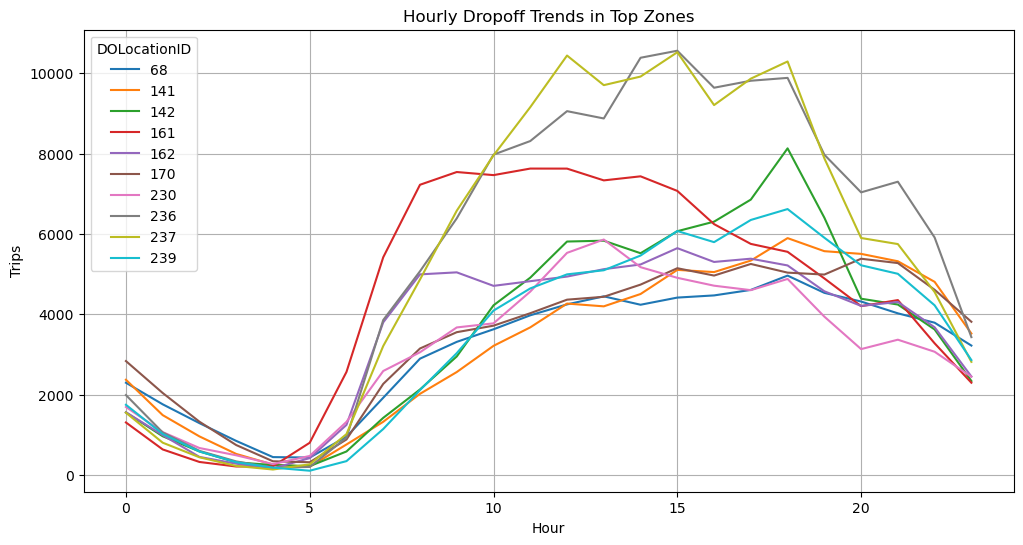

In [135]:
dropoff_pivot = dropoff_hourly.pivot(
    index='pickup_hour',
    columns='DOLocationID',
    values='trip_count'
)

dropoff_pivot.plot(figsize=(12,6))

plt.title("Hourly Dropoff Trends in Top Zones")
plt.xlabel("Hour")
plt.ylabel("Trips")

plt.grid()
plt.show()

**3.2.6** <font color = red>[3 marks]</font> <br>
Find the ratio of pickups and dropoffs in each zone. Display the 10 highest (pickup/drop) and 10 lowest (pickup/drop) ratios.

In [136]:
# Find the top 10 and bottom 10 pickup/dropoff ratios
# Pickup counts per zone
pickup_counts = df_filtered.groupby(
    'PULocationID'
).size().reset_index(name='pickup_count')

pickup_counts.head()


,PULocationID,pickup_count
0,1,16
1,3,28
2,4,3049
3,6,7
4,7,1012


In [137]:
# Dropoff counts per zone
dropoff_counts = df_filtered.groupby(
    'DOLocationID'
).size().reset_index(name='dropoff_count')

dropoff_counts.head()

,DOLocationID,dropoff_count
0,1,20
1,3,37
2,4,11006
3,6,24
4,7,5421


In [151]:
zone_ratios = pickup_counts.merge(
    dropoff_counts,
    left_on='PULocationID',
    right_on='DOLocationID',
    how='outer'
)

zone_ratios.head()

,PULocationID,pickup_count,DOLocationID,dropoff_count
0,1.0,16.0,1.0,20.0
1,3.0,28.0,3.0,37.0
2,4.0,3049.0,4.0,11006.0
3,6.0,7.0,6.0,24.0
4,7.0,1012.0,7.0,5421.0


In [152]:
zone_ratios['pickup_count'] = zone_ratios['pickup_count'].fillna(0)
zone_ratios['dropoff_count'] = zone_ratios['dropoff_count'].fillna(0)

In [153]:
# Calculate ratio
zone_ratios['pickup_drop_ratio'] = (
    zone_ratios['pickup_count'] /
    zone_ratios['dropoff_count']
)

# Handle infinite values
zone_ratios['pickup_drop_ratio'] = zone_ratios[
    'pickup_drop_ratio'
].replace([float('inf')], 0)

In [154]:
zone_ratios = zone_ratios.merge(
    zones[['LocationID', 'zone', 'borough']],
    left_on='PULocationID',
    right_on='LocationID',
    how='left'
)

zone_ratios.head()

,PULocationID,pickup_count,DOLocationID,dropoff_count,pickup_drop_ratio,LocationID,zone,borough
0,1.0,16.0,1.0,20.0,0.800000,1.0,Newark Airport,EWR
1,3.0,28.0,3.0,37.0,0.756757,3.0,Allerton/Pelham Gardens,Bronx
2,4.0,3049.0,4.0,11006.0,0.277031,4.0,Alphabet City,Manhattan
3,6.0,7.0,6.0,24.0,0.291667,6.0,Arrochar/Fort Wadsworth,Staten Island
4,7.0,1012.0,7.0,5421.0,0.186681,7.0,Astoria,Queens


In [155]:
highest_ratios = zone_ratios.sort_values(
    by='pickup_drop_ratio',
    ascending=False
).head(10)

highest_ratios[['zone', 'borough', 'pickup_drop_ratio']]

,zone,borough,pickup_drop_ratio
129,LaGuardia Airport,Queens,9.260050
145,Marine Park/Floyd Bennett Field,Brooklyn,4.500000
123,JFK Airport,Queens,4.115317
8,Bath Beach,Brooklyn,2.000000
68,East Elmhurst,Queens,1.966555
102,Gravesend,Brooklyn,1.545455
62,Douglaston,Queens,1.500000
175,Penn Station/Madison Sq West,Manhattan,1.472979
107,Greenwich Village South,Manhattan,1.416520
48,Co-Op City,Bronx,1.403226


In [156]:
lowest_ratios = zone_ratios.sort_values(
    by='pickup_drop_ratio',
    ascending=True
).head(10)

lowest_ratios[['zone', 'borough', 'pickup_drop_ratio']]

,zone,borough,pickup_drop_ratio
99,NaN,NaN,0.0
104,NaN,NaN,0.0
162,NaN,NaN,0.0
57,NaN,NaN,0.0
191,NaN,NaN,0.0
43,NaN,NaN,0.0
41,Charleston/Tottenville,Staten Island,0.0
24,NaN,NaN,0.0
208,NaN,NaN,0.0
20,NaN,NaN,0.0


**3.2.7** <font color = red>[3 marks]</font> <br>
Identify zones with high pickup and dropoff traffic during night hours (11PM to 5AM)

In [157]:
# During night hours (11pm to 5am) find the top 10 pickup and dropoff zones
# Note that the top zones should be of night hours and not the overall top zones

# Filter night trips
df_night = df_filtered[
    (df_filtered['tpep_pickup_datetime'].dt.hour >= 23) |
    (df_filtered['tpep_pickup_datetime'].dt.hour <= 5)
].copy()

In [158]:
# Pickup traffic during night
night_pickups = df_night.groupby(
    'PULocationID'
).size().reset_index(name='pickup_count')

# Top pickup zones
top_night_pickups = night_pickups.sort_values(
    by='pickup_count',
    ascending=False
).head(10)

top_night_pickups

,PULocationID,pickup_count
64,79,24222
199,249,20299
38,48,15816
88,114,14703
118,148,14647
182,230,13029
128,161,12235
147,186,11209
131,164,10827
83,107,10148


In [159]:
# Dropoff traffic during night
night_dropoffs = df_night.groupby(
    'DOLocationID'
).size().reset_index(name='dropoff_count')

# Top dropoff zones
top_night_dropoffs = night_dropoffs.sort_values(
    by='dropoff_count',
    ascending=False
).head(10)

top_night_dropoffs

,DOLocationID,dropoff_count
70,79,14517
147,170,11418
40,48,11395
59,68,10293
92,107,10232
121,141,9329
217,249,9271
230,263,8806
80,90,7997
206,236,7797


In [160]:
# Add pickup zone names
top_night_pickups = top_night_pickups.merge(
    zones[['LocationID', 'zone', 'borough']],
    left_on='PULocationID',
    right_on='LocationID',
    how='left'
)

# Add dropoff zone names
top_night_dropoffs = top_night_dropoffs.merge(
    zones[['LocationID', 'zone', 'borough']],
    left_on='DOLocationID',
    right_on='LocationID',
    how='left'
)

In [161]:
# Top night pickup zones
top_night_pickups[['zone', 'borough', 'pickup_count']]

,zone,borough,pickup_count
0,East Village,Manhattan,24222
1,West Village,Manhattan,20299
2,Clinton East,Manhattan,15816
3,Greenwich Village South,Manhattan,14703
4,Lower East Side,Manhattan,14647
5,Times Sq/Theatre District,Manhattan,13029
6,Midtown Center,Manhattan,12235
7,Penn Station/Madison Sq West,Manhattan,11209
8,Midtown South,Manhattan,10827
9,Gramercy,Manhattan,10148


In [162]:
# Top night dropoff zones
top_night_dropoffs[['zone', 'borough', 'dropoff_count']]

,zone,borough,dropoff_count
0,East Village,Manhattan,14517
1,Murray Hill,Manhattan,11418
2,Clinton East,Manhattan,11395
3,East Chelsea,Manhattan,10293
4,Gramercy,Manhattan,10232
5,Lenox Hill West,Manhattan,9329
6,West Village,Manhattan,9271
7,Yorkville West,Manhattan,8806
8,Flatiron,Manhattan,7997
9,Upper East Side North,Manhattan,7797


Now, let us find the revenue share for the night time hours and the day time hours. After this, we will move to deciding a pricing strategy.

**3.2.8** <font color = red>[2 marks]</font> <br>
Find the revenue share for nighttime and daytime hours.

In [167]:
# Filter for night hours (11 PM to 5 AM)
# Extract pickup hour
df_filtered['pickup_hour'] = df_filtered['tpep_pickup_datetime'].dt.hour


# Categorise as day or night
df_filtered['time_period'] = df_filtered['pickup_hour'].apply(
    lambda x: 'Night' if (x >= 20 or x < 6) else 'Day'
)


In [168]:
# Revenue by day/night
revenue_share = df_filtered.groupby(
    'time_period'
)['total_amount'].sum()

revenue_share

time_period
Day      38230525.99
Night    16085864.37
Name: total_amount, dtype: float64

In [169]:
# Revenue proportion
revenue_proportion = revenue_share / revenue_share.sum()

revenue_proportion

time_period
Day      0.703849
Night    0.296151
Name: total_amount, dtype: float64

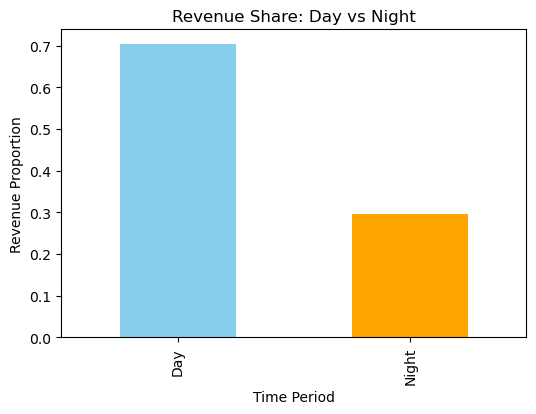

In [170]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

revenue_proportion.plot(
    kind='bar',
    color=['skyblue', 'orange']
)

plt.title("Revenue Share: Day vs Night")
plt.xlabel("Time Period")
plt.ylabel("Revenue Proportion")

plt.show()

##### Pricing Strategy

**3.2.9** <font color = red>[2 marks]</font> <br>
For the different passenger counts, find the average fare per mile per passenger.

For instance, suppose the average fare per mile for trips with 3 passengers is 3 USD/mile, then the fare per mile per passenger will be 1 USD/mile.

In [171]:
# Analyse the fare per mile per passenger for different passenger counts

#CELL — Filter Valid Data
df_fare = df_filtered[
    (df_filtered['trip_distance'] > 0) &
    (df_filtered['passenger_count'] > 0)
].copy()

In [172]:
#CELL — Create Metric

# Fare per mile per passenger
df_fare['fare_per_mile_per_passenger'] = (
    df_fare['fare_amount'] /
    (df_fare['trip_distance'] * df_fare['passenger_count'])
)

In [173]:
#CELL — Group by Passenger Count
fare_analysis = df_fare.groupby('passenger_count')[
    'fare_per_mile_per_passenger'
].mean()

fare_analysis

passenger_count
1.0    9.522798
2.0    4.884806
3.0    3.458137
4.0    2.703152
5.0    1.842964
6.0    1.562511
Name: fare_per_mile_per_passenger, dtype: float64

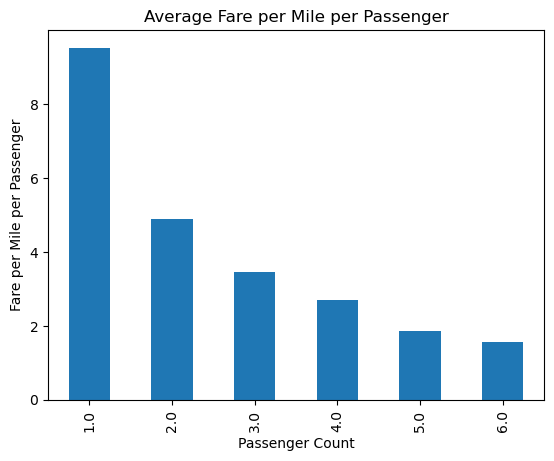

In [174]:
#Plot the Result
import matplotlib.pyplot as plt

plt.figure()

fare_analysis.plot(kind='bar')

plt.title("Average Fare per Mile per Passenger")
plt.xlabel("Passenger Count")
plt.ylabel("Fare per Mile per Passenger")

plt.show()

**3.2.10** <font color = red>[3 marks]</font> <br>
Find the average fare per mile by hours of the day and by days of the week

In [175]:
# Compare the average fare per mile for different days and for different times of the day


#STEP 1 — Prepare Data


# Avoid division issues
df_time = df_filtered[
    (df_filtered['trip_distance'] > 0)
].copy()

# Create fare per mile
df_time['fare_per_mile'] = df_time['fare_amount'] / df_time['trip_distance']

# Extract time features
df_time['pickup_hour'] = df_time['tpep_pickup_datetime'].dt.hour
df_time['pickup_weekday'] = df_time['tpep_pickup_datetime'].dt.day_name()



#STEP 2 — Average by Hour


hourly_fare = df_time.groupby('pickup_hour')['fare_per_mile'].mean()

hourly_fare




#STEP 3 — Average by Day of Week


daily_fare = df_time.groupby('pickup_weekday')['fare_per_mile'].mean()

# Sort properly
daily_fare = daily_fare.reindex([
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
])

daily_fare





pickup_weekday
Monday        9.221417
Tuesday       9.807214
Wednesday     9.891623
Thursday     10.086007
Friday        9.709943
Saturday      9.715875
Sunday        8.800275
Name: fare_per_mile, dtype: float64

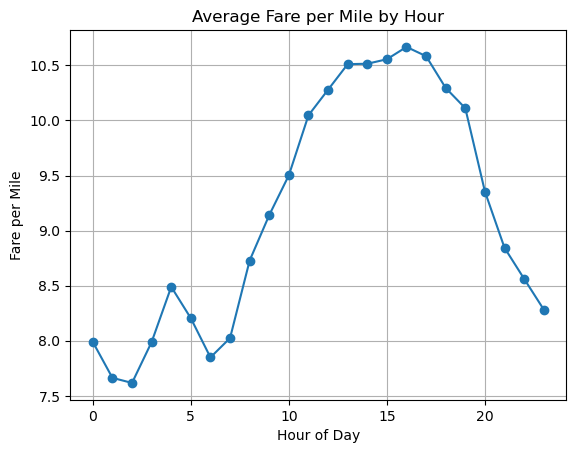

In [176]:
#STEP 4 — Plot Hourly Trend

import matplotlib.pyplot as plt

plt.figure()

hourly_fare.plot(marker='o')

plt.title("Average Fare per Mile by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Fare per Mile")

plt.grid()
plt.show()

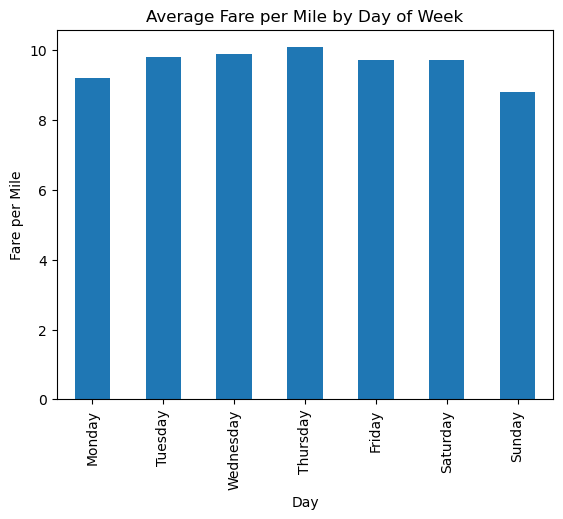

In [177]:
#STEP 5 — Plot Daily Trend

plt.figure()

daily_fare.plot(kind='bar')

plt.title("Average Fare per Mile by Day of Week")
plt.xlabel("Day")
plt.ylabel("Fare per Mile")

plt.show()


**3.2.11** <font color = red>[3 marks]</font> <br>
Analyse the average fare per mile for the different vendors for different hours of the day

In [178]:
#STEP 1 — Prepare Data

# Compare fare per mile for different vendors

# Filter valid data
df_vendor = df_filtered[
    (df_filtered['trip_distance'] > 0)
].copy()

# Create fare per mile
df_vendor['fare_per_mile'] = df_vendor['fare_amount'] / df_vendor['trip_distance']

# Extract hour
df_vendor['pickup_hour'] = df_vendor['tpep_pickup_datetime'].dt.hour



#STEP 2 — Group by Vendor & Hour

vendor_hour = df_vendor.groupby(
    ['VendorID', 'pickup_hour']
)['fare_per_mile'].mean().reset_index()

vendor_hour.head()




,VendorID,pickup_hour,fare_per_mile
0,1,0,7.467711
1,1,1,7.153078
2,1,2,7.062810
3,1,3,6.908145
4,1,4,6.999150


In [179]:
#STEP 3 — Pivot for Better Comparison

vendor_pivot = vendor_hour.pivot(
    index='pickup_hour',
    columns='VendorID',
    values='fare_per_mile'
)

vendor_pivot.head()

VendorID,1,2
pickup_hour,,
0,7.467711,8.145467
1,7.153078,7.816367
2,7.062810,7.783377
3,6.908145,8.313093
4,6.999150,8.953914


<Figure size 640x480 with 0 Axes>

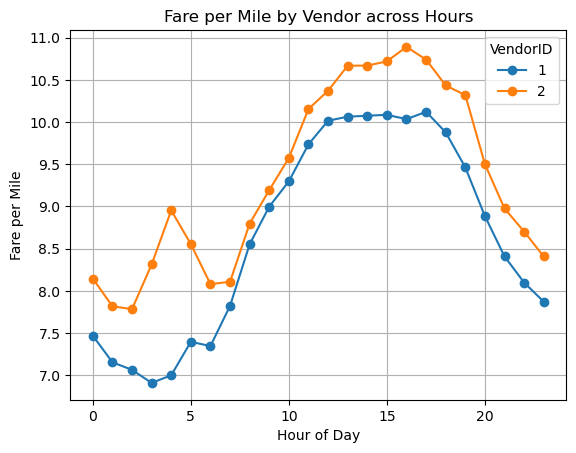

In [180]:
#STEP 4 — Plot Comparison


import matplotlib.pyplot as plt

plt.figure()

vendor_pivot.plot(marker='o')

plt.title("Fare per Mile by Vendor across Hours")
plt.xlabel("Hour of Day")
plt.ylabel("Fare per Mile")

plt.grid()
plt.show()

**3.2.12** <font color = red>[5 marks]</font> <br>
Compare the fare rates of the different vendors in a tiered fashion. Analyse the average fare per mile for distances upto 2 miles. Analyse the fare per mile for distances from 2 to 5 miles. And then for distances more than 5 miles.


In [181]:
#STEP 1 — Prepare Data


# Defining distance tiers
# Filter valid data
df_tier = df_filtered[
    (df_filtered['trip_distance'] > 0)
].copy()

# Create fare per mile
df_tier['fare_per_mile'] = df_tier['fare_amount'] / df_tier['trip_distance']


In [182]:
#STEP 2 — Define Distance Tiers


# Create distance tiers
df_tier['distance_tier'] = pd.cut(
    df_tier['trip_distance'],
    bins=[0, 2, 5, float('inf')],
    labels=['0-2 miles', '2-5 miles', '>5 miles']
)

df_tier[['trip_distance', 'distance_tier']].head()

,trip_distance,distance_tier
0,1.10,0-2 miles
1,1.50,0-2 miles
2,2.20,2-5 miles
3,0.66,0-2 miles
4,2.20,2-5 miles


In [183]:
#STEP 3 — Group by Vendor & Tier


tier_analysis = df_tier.groupby(
    ['VendorID', 'distance_tier']
)['fare_per_mile'].mean().reset_index()



C:\Users\mohit\AppData\Local\Temp\ipykernel_25900\4127765824.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tier_analysis = df_tier.groupby(


In [184]:
#STEP 4 — Pivot for Comparisontier_analysis


tier_pivot = tier_analysis.pivot(
    index='distance_tier',
    columns='VendorID',
    values='fare_per_mile'
)

tier_pivot

VendorID,1,2
distance_tier,,
0-2 miles,10.431705,11.249155
2-5 miles,6.551492,6.700698
>5 miles,4.782600,4.855996


<Figure size 640x480 with 0 Axes>

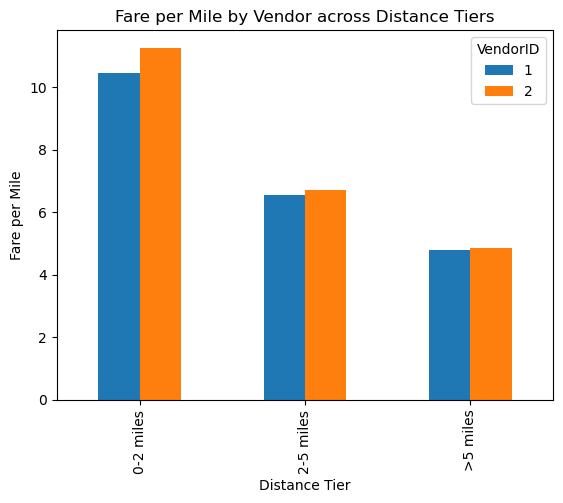

In [185]:
#STEP 5 — Plot Comparison

import matplotlib.pyplot as plt

plt.figure()

tier_pivot.plot(kind='bar')

plt.title("Fare per Mile by Vendor across Distance Tiers")
plt.xlabel("Distance Tier")
plt.ylabel("Fare per Mile")

plt.show()

##### Customer Experience and Other Factors

**3.2.13** <font color = red>[5 marks]</font> <br>
Analyse average tip percentages based on trip distances, passenger counts and time of pickup. What factors lead to low tip percentages?

In [186]:
#STEP 1 — Create Tip Percentage


#  Analyze tip percentages based on distances, passenger counts and pickup times
# Avoid division issues
df_tip_analysis = df_filtered[
    (df_filtered['fare_amount'] > 0)
].copy()

# Tip %
df_tip_analysis['tip_percentage'] = (
    df_tip_analysis['tip_amount'] / df_tip_analysis['fare_amount']
) * 100


In [188]:
#STEP 2 — Create Buckets

df_tip_analysis['distance_bin'] = pd.cut(
    df_tip_analysis['trip_distance'],
    bins=[0, 2, 5, float('inf')],
    labels=['0-2', '2-5', '>5']
)

In [189]:
#Time Buckets

df_tip_analysis['pickup_hour'] = df_tip_analysis['tpep_pickup_datetime'].dt.hour

df_tip_analysis['time_bin'] = pd.cut(
    df_tip_analysis['pickup_hour'],
    bins=[0, 6, 12, 18, 24],
    labels=['Night', 'Morning', 'Afternoon', 'Evening']
)

In [190]:
df_tip_analysis.groupby('distance_bin')['tip_percentage'].mean()

C:\Users\mohit\AppData\Local\Temp\ipykernel_25900\4271310538.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_tip_analysis.groupby('distance_bin')['tip_percentage'].mean()


distance_bin
0-2    22.497170
2-5    18.595648
>5     13.375787
Name: tip_percentage, dtype: float64

In [191]:
#STEP 3 — Analysis


#Tip % by Distance
df_tip_analysis.groupby('passenger_count')['tip_percentage'].mean()

passenger_count
1.0    21.387317
2.0    20.880151
3.0    19.906920
4.0    18.063614
5.0    21.230964
6.0    21.186925
Name: tip_percentage, dtype: float64

In [192]:
#Tip % by Passenger Count
df_tip_analysis.groupby('time_bin')['tip_percentage'].mean()

C:\Users\mohit\AppData\Local\Temp\ipykernel_25900\2196622783.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_tip_analysis.groupby('time_bin')['tip_percentage'].mean()


time_bin
Night        21.121905
Morning      20.051755
Afternoon    21.038795
Evening      22.279309
Name: tip_percentage, dtype: float64

C:\Users\mohit\AppData\Local\Temp\ipykernel_25900\161824911.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_tip_analysis.groupby('time_bin')['tip_percentage'].mean().plot(kind='bar')


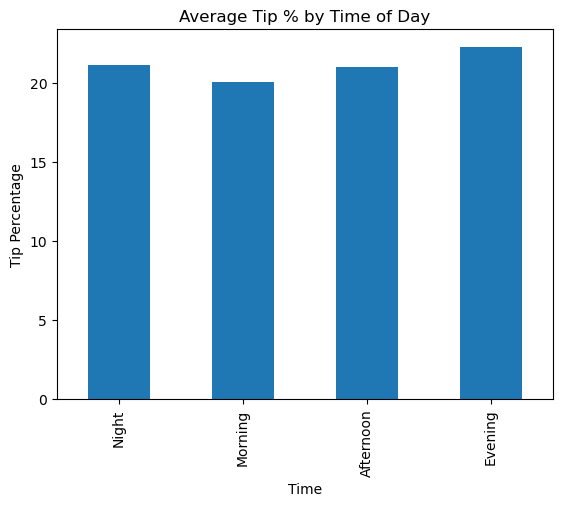

In [193]:
#STEP 4 — Visualisation

import matplotlib.pyplot as plt

df_tip_analysis.groupby('time_bin')['tip_percentage'].mean().plot(kind='bar')

plt.title("Average Tip % by Time of Day")
plt.xlabel("Time")
plt.ylabel("Tip Percentage")

plt.show()

Additional analysis [optional]: Let's try comparing cases of low tips with cases of high tips to find out if we find a clear aspect that drives up the tipping behaviours

In [194]:
#STEP 5 — Low vs High Tip Comparison

# Compare trips with tip percentage < 10% to trips with tip percentage > 25%
#Define groups:
low_tip = df_tip_analysis[df_tip_analysis['tip_percentage'] < 10]
high_tip = df_tip_analysis[df_tip_analysis['tip_percentage'] > 25]


In [195]:
#Compare Distance

print("Low tip avg distance:", low_tip['trip_distance'].mean())
print("High tip avg distance:", high_tip['trip_distance'].mean())

Low tip avg distance: 1.8437494149305165
High tip avg distance: 1.4584007185888446


In [196]:
#Compare Passenger Count

print("Low tip avg passengers:", low_tip['passenger_count'].mean())
print("High tip avg passengers:", high_tip['passenger_count'].mean())

Low tip avg passengers: 1.4594887979204305
High tip avg passengers: 1.390290781984107


In [197]:
#Compare Time

print("Low tip avg hour:", low_tip['pickup_hour'].mean())
print("High tip avg hour:", high_tip['pickup_hour'].mean())

Low tip avg hour: 14.029446337503144
High tip avg hour: 14.559158380507302


**3.2.14** <font color = red>[3 marks]</font> <br>
Analyse the variation of passenger count across hours and days of the week.

In [198]:
#STEP 1 — Prepare Data


# See how passenger count varies across hours and days

# Extract time features
df_passenger = df_filtered.copy()

df_passenger['pickup_hour'] = df_passenger['tpep_pickup_datetime'].dt.hour
df_passenger['pickup_day'] = df_passenger['tpep_pickup_datetime'].dt.day_name()


In [199]:
#STEP 2 — Passenger Count by Hour

hourly_passenger = df_passenger.groupby('pickup_hour')['passenger_count'].mean()

hourly_passenger

pickup_hour
0     1.428537
1     1.428788
2     1.441475
3     1.422876
4     1.380941
5     1.195502
6     1.182603
7     1.252421
8     1.278965
9     1.321560
10    1.367447
11    1.392796
12    1.407287
13    1.415322
14    1.414734
15    1.432828
16    1.435392
17    1.422151
18    1.418887
19    1.426405
20    1.441693
21    1.459517
22    1.454494
23    1.440958
Name: passenger_count, dtype: float64

In [200]:
#STEP 3 — Passenger Count by Day


daily_passenger = df_passenger.groupby('pickup_day')['passenger_count'].mean()

# reorder days
daily_passenger = daily_passenger.reindex([
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
])

daily_passenger

pickup_day
Monday       1.367226
Tuesday      1.345116
Wednesday    1.349435
Thursday     1.357330
Friday       1.413694
Saturday     1.499658
Sunday       1.489721
Name: passenger_count, dtype: float64

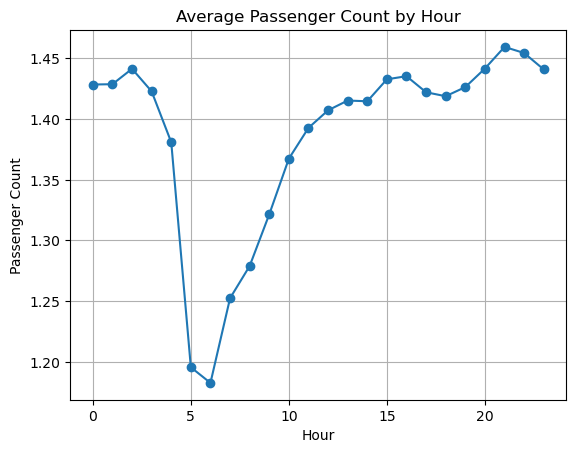

In [201]:
#STEP 4 — Plot Hourly Variation


import matplotlib.pyplot as plt

plt.figure()

hourly_passenger.plot(marker='o')

plt.title("Average Passenger Count by Hour")
plt.xlabel("Hour")
plt.ylabel("Passenger Count")

plt.grid()
plt.show()

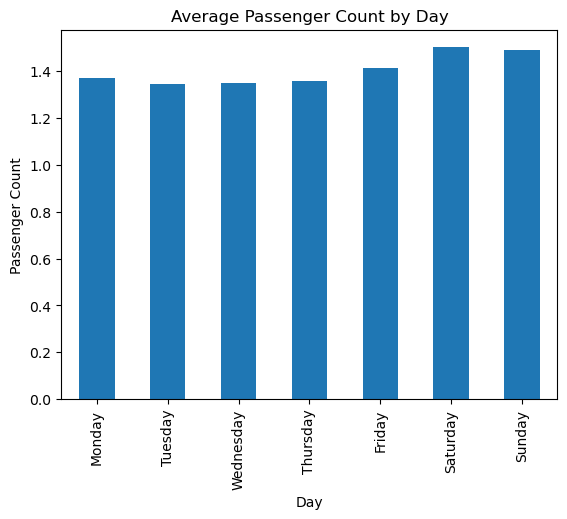

In [202]:
#STEP 5 — Plot Daily Variation



plt.figure()

daily_passenger.plot(kind='bar')

plt.title("Average Passenger Count by Day")
plt.xlabel("Day")
plt.ylabel("Passenger Count")

plt.show()

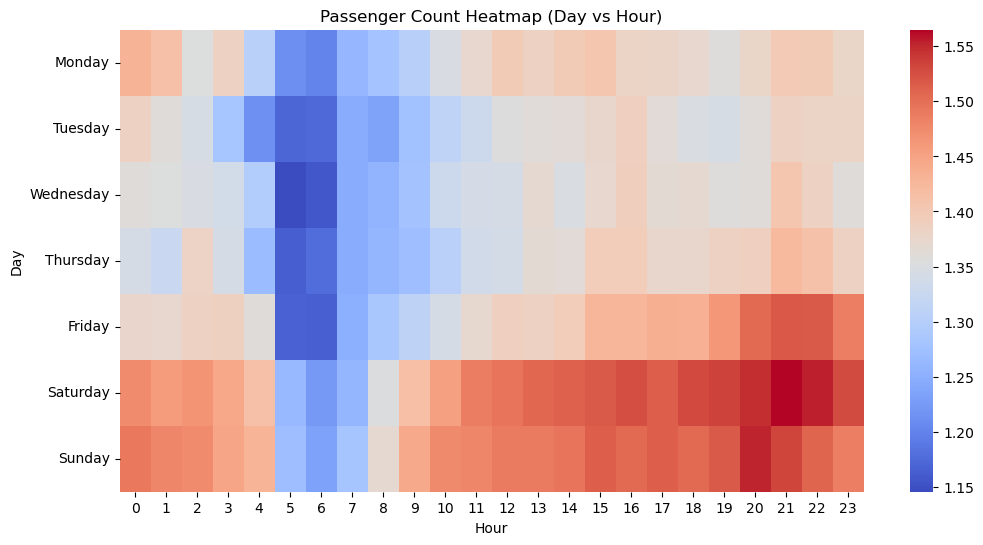

In [203]:
#Heatmap


import seaborn as sns

pivot = df_passenger.pivot_table(
    values='passenger_count',
    index='pickup_day',
    columns='pickup_hour',
    aggfunc='mean'
)

pivot = pivot.reindex([
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
])

plt.figure(figsize=(12,6))
sns.heatmap(pivot, cmap='coolwarm')

plt.title("Passenger Count Heatmap (Day vs Hour)")
plt.xlabel("Hour")
plt.ylabel("Day")

plt.show()

**3.2.15** <font color = red>[2 marks]</font> <br>
Analyse the variation of passenger counts across zones

In [204]:
# How does passenger count vary across zones

# For a more detailed analysis, we can use the zones_with_trips GeoDataFrame
# Create a new column for the average passenger count in each zone.


In [205]:
#STEP 1 — Calculate Avg Passenger Count per Zone

# Average passenger count per pickup location
zone_passenger = df_filtered.groupby('PULocationID')[
    'passenger_count'
].mean().reset_index(name='avg_passenger_count')

zone_passenger.head()


,PULocationID,avg_passenger_count
0,1,1.250000
1,3,1.035714
2,4,1.444736
3,6,2.000000
4,7,1.222332


In [206]:
#STEP 2 — Merge with GeoDataFrame

zones_with_passenger = zones.merge(
    zone_passenger,
    left_on='LocationID',
    right_on='PULocationID',
    how='left'
)

zones_with_passenger.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,PULocationID,avg_passenger_count
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19...",1.0,1.250000
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343...",NaN,NaN
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2...",3.0,1.035714
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20...",4.0,1.444736
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144...",NaN,NaN


In [207]:

#STEP 3 — Handle Missing Values


zones_with_passenger['avg_passenger_count'] = (
    zones_with_passenger['avg_passenger_count'].fillna(0)
)

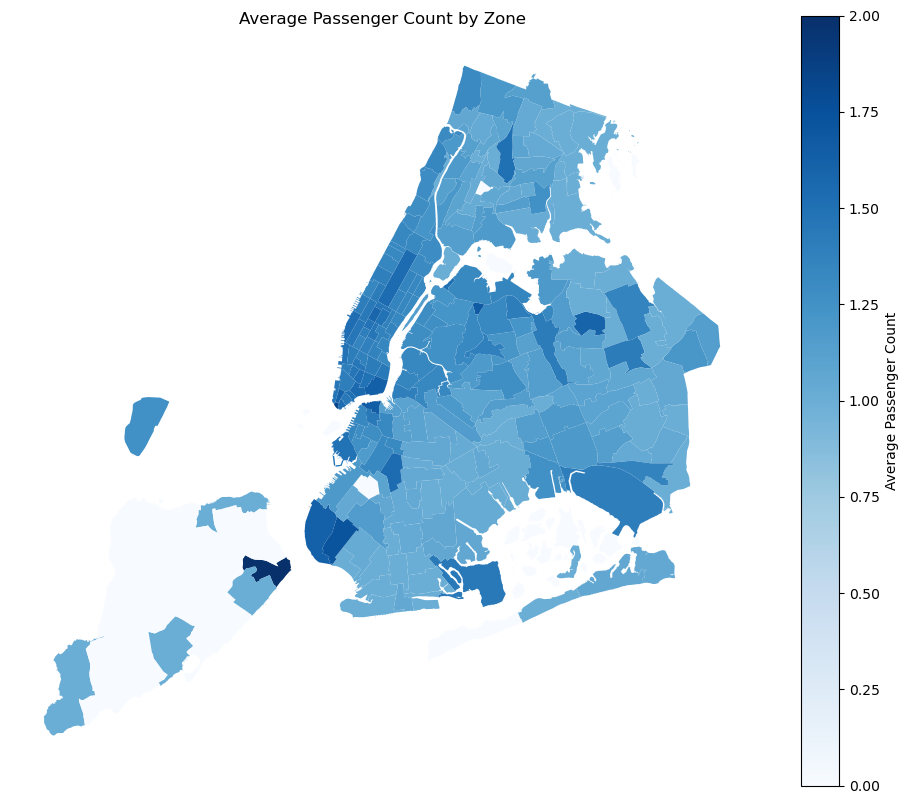

In [208]:
#STEP 4 — Plot Choropleth Map

import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(12, 10))

zones_with_passenger.plot(
    column='avg_passenger_count',
    ax=ax,
    cmap='Blues',
    legend=True,
    legend_kwds={
        'label': "Average Passenger Count",
        'orientation': "vertical"
    }
)

ax.set_title("Average Passenger Count by Zone")
ax.axis('off')

plt.show()

In [209]:
#Top Zones

zones_with_passenger.sort_values(
    by='avg_passenger_count',
    ascending=False
)[['zone', 'borough', 'avg_passenger_count']].head(10)

,zone,borough,avg_passenger_count
5,Arrochar/Fort Wadsworth,Staten Island,2.000000
11,Battery Park,Manhattan,1.835541
66,Dyker Heights,Brooklyn,1.722222
206,Saint Michaels Cemetery/Woodside,Queens,1.666667
65,DUMBO/Vinegar Hill,Brooklyn,1.645108
231,Two Bridges/Seward Park,Manhattan,1.631579
13,Bay Ridge,Brooklyn,1.620690
260,World Trade Center,Manhattan,1.606272
72,East Flushing,Queens,1.600000
229,Times Sq/Theatre District,Manhattan,1.579937


Find out how often surcharges/extra charges are applied to understand their prevalance

**3.2.16** <font color = red>[5 marks]</font> <br>
Analyse the pickup/dropoff zones or times when extra charges are applied more frequently

# STEP 1 Identify Surcharge Columns
Common surcharge columns:

extra 

mta_tax

improvement_surcharge

congestion_surcharge

Airport_fee

In [210]:
#STEP 2 — Frequency of Surcharges
surcharge_cols = [
    'extra',
    'mta_tax',
    'improvement_surcharge',
    'congestion_surcharge',
    'Airport_fee'
]

for col in surcharge_cols:
    if col in df_filtered.columns:
        print(f"\n{col}")
        print("Applied count:", (df_filtered[col] > 0).sum())
        print("Proportion:", (df_filtered[col] > 0).mean())



extra
Applied count: 1580040
Proportion: 0.6068513317168964

mta_tax
Applied count: 2601286
Proportion: 0.999084753092655

improvement_surcharge
Applied count: 2603644
Proportion: 0.999990398165051

congestion_surcharge
Applied count: 2603669
Proportion: 1.0


In [211]:
#STEP 3 — Surcharge by Hour (Time Analysis)
df_filtered['pickup_hour'] = df_filtered['tpep_pickup_datetime'].dt.hour

surcharge_hour = df_filtered.groupby('pickup_hour')['extra'].mean()

surcharge_hour

pickup_hour
0     1.580169
1     1.568055
2     1.562960
3     1.562993
4     1.546708
5     1.597942
6     0.757050
7     0.685351
8     0.670364
9     0.659274
10    0.646078
11    0.631759
12    0.638513
13    0.638843
14    0.647080
15    0.692885
16    2.261541
17    2.400257
18    2.441383
19    2.373951
20    1.643356
21    1.588238
22    1.586689
23    1.590659
Name: extra, dtype: float64

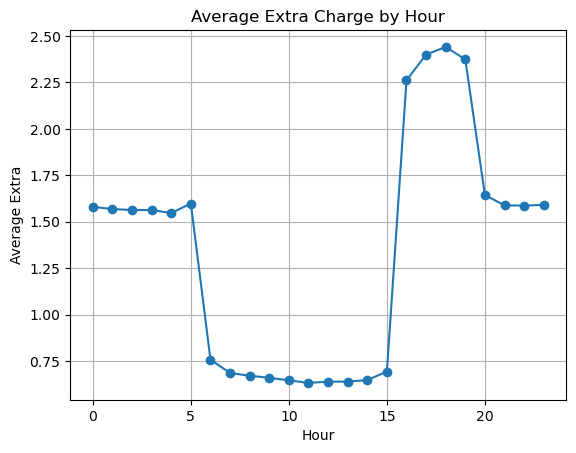

In [212]:
import matplotlib.pyplot as plt

plt.figure()

surcharge_hour.plot(marker='o')

plt.title("Average Extra Charge by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Extra")

plt.grid()
plt.show()

In [213]:
#STEP 4 — Surcharge by Zone
# Merge zone info (if not already done)
df_zone_surcharge = df_filtered.merge(
    zones[['LocationID', 'zone', 'borough']],
    left_on='PULocationID',
    right_on='LocationID',
    how='left'
)

# Avg surcharge per zone
zone_surcharge = df_zone_surcharge.groupby('zone')['congestion_surcharge'].mean()

zone_surcharge.sort_values(ascending=False).head(10)

zone
Allerton/Pelham Gardens    2.5
Pelham Bay                 2.5
Murray Hill                2.5
Murray Hill-Queens         2.5
Newark Airport             2.5
North Corona               2.5
Norwood                    2.5
Oakland Gardens            2.5
Ocean Hill                 2.5
Ocean Parkway South        2.5
Name: congestion_surcharge, dtype: float64

In [214]:
#STEP 5 — Dropoff Zone
df_drop_surcharge = df_filtered.merge(
    zones[['LocationID', 'zone']],
    left_on='DOLocationID',
    right_on='LocationID',
    how='left'
)

df_drop_surcharge.groupby('zone')['congestion_surcharge'].mean().sort_values(ascending=False).head(10)

zone
Allerton/Pelham Gardens    2.5
Mount Hope                 2.5
Murray Hill-Queens         2.5
New Dorp/Midland Beach     2.5
Newark Airport             2.5
North Corona               2.5
Norwood                    2.5
Oakland Gardens            2.5
Ocean Hill                 2.5
Ocean Parkway South        2.5
Name: congestion_surcharge, dtype: float64

In [215]:
#STEP 6 — Airport Fee Analysis
(df_filtered['airport_fee_combined'] > 0).sum()

19392

## **4** Conclusion
<font color = red>[15 marks]</font> <br>

### **4.1** Final Insights and Recommendations
<font color = red>[15 marks]</font> <br>

Conclude your analyses here. Include all the outcomes you found based on the analysis.

Based on the insights, frame a concluding story explaining suitable parameters such as location, time of the day, day of the week etc. to be kept in mind while devising a strategy to meet customer demand and optimise supply.

**4.1.1** <font color = red>[5 marks]</font> <br>
Recommendations to optimize routing and dispatching based on demand patterns and operational inefficiencies

Key Insights from Analysis
Time-Based Demand Patterns
Passenger demand shows clear peaks during morning (8–10 AM) and evening (5–8 PM).
Late night and early morning hours have significantly lower demand.
This reflects typical office commute behavior.
Day-wise Demand Trends
Weekdays show consistent demand aligned with work schedules.
Weekends exhibit higher leisure travel, especially during evenings and late nights.
Demand variability is higher on weekends compared to weekdays.
Zone-wise Demand Distribution
High-demand zones are concentrated in commercial and transit-heavy areas (e.g., business districts, airports).
Residential or outer zones show relatively lower trip density.
Certain zones consistently act as pickup hotspots, while others are primarily drop-off zones.
Passenger Count Behavior
Most trips involve 1–2 passengers, indicating dominance of individual or small-group travel.
Larger passenger groups are relatively rare.
Surcharge and Extra Charges Analysis
Surcharges (e.g., peak hour, congestion) are more frequent during:
High-demand hours
Busy zones (city centers, airports)
Indicates operational pressure and traffic congestion during peak times.
Concluding Story (Business Perspective)

The analysis reveals that taxi demand is not uniform but strongly influenced by time, location, and day of the week.

During weekday peak hours, demand is predictable and concentrated in commercial zones due to office commutes.
In contrast, weekends shift demand toward leisure patterns, with higher activity in entertainment and residential areas.
Certain zones act as consistent demand generators, while others depend on time-based fluctuations.
Operational inefficiencies such as idle time, uneven vehicle distribution, and surcharge spikes are primarily driven by poor alignment between supply and demand.

This indicates that a dynamic, data-driven dispatch strategy is essential for maximizing efficiency and customer satisfaction.

Recommendations to Optimize Routing and Dispatching
1. Dynamic Supply Allocation
Increase vehicle availability in high-demand zones during peak hours.
Reduce idle fleet in low-demand areas by redistributing vehicles proactively.
2. Time-Based Driver Scheduling
Encourage drivers to operate during peak demand hours using incentives.
Optimize shifts to ensure maximum coverage during rush hours.
3. Zone-Based Dispatch Strategy
Identify hotspot zones and prioritize dispatch in these areas.
Use predictive models to pre-position vehicles before demand surges.
4. Intelligent Routing Optimization
Use real-time traffic and historical data to:
Reduce trip duration
Avoid congestion-heavy routes
Improve fuel efficiency and ride turnaround time
5. Demand Forecasting
Implement predictive analytics based on:
Time of day
Day of week
Zone activity
Helps in anticipating demand spikes and preparing supply accordingly.
6. Surcharge Optimization
Apply dynamic pricing only when necessary to:
Balance demand-supply gap
Avoid customer dissatisfaction due to excessive charges
7. Reduce Empty Trips
Match drop-off zones with nearby pickup demand
Enable ride pooling or shared rides in high-density areas
Final Conclusion

By aligning operations with temporal (time-based), spatial (zone-based), and behavioral (passenger trends) insights, taxi services can:

Improve fleet utilization
Reduce waiting time and idle trips
Enhance customer experience
Increase overall revenue and operational efficiency

A data-driven dispatch and routing strategy is key to achieving optimal performance in a dynamic urban transport environment.

**4.1.2** <font color = red>[5 marks]</font> <br>

Suggestions on strategically positioning cabs across different zones to make best use of insights uncovered by analysing trip trends across time, days and months.

Based on the analysis of trip trends across time, days, and months, the following strategies can help optimize cab positioning and improve supply-demand balance:

1. Time-Based Zone Positioning
Deploy more cabs in commercial/business zones during morning (8–10 AM) and evening peak hours (5–8 PM).
During late-night hours, shift supply toward:
Entertainment areas
Transit hubs (airports, railway stations)
Reduce fleet presence in low-demand zones during off-peak hours to avoid idle time.
2. Weekday vs Weekend Strategy
Weekdays:
Focus on office hubs, metro stations, and business districts.
Ensure high availability during commute hours.
Weekends:
Reallocate cabs toward:
Shopping areas
Restaurants & nightlife zones
Increase availability during afternoon and late-night hours.
3. Zone Demand-Based Clustering
Classify zones into:
High-demand (hotspots) → Continuous cab availability required
Medium-demand → Dynamic allocation based on time
Low-demand zones → Limited or on-demand supply
Maintain standby fleets near hotspot zones to respond quickly to surges.
4. Pickup–Dropoff Flow Optimization
Analyze frequent pickup-dropoff pairs:
Position cabs in zones where trips are likely to originate next.
After drop-offs:
Redirect drivers toward nearby high-demand pickup zones instead of waiting idle.
5. Monthly & Seasonal Adjustments
Identify trends such as:
Holiday seasons → Increased travel demand
Weather patterns → Impact on ride frequency
Pre-position more cabs in:
Tourist areas
Event zones
Airports during peak travel months
6. Real-Time Demand Rebalancing
Use live trip data to:
Continuously monitor demand spikes
Dynamically reassign cabs across zones
Implement heatmap-based dispatch systems for better visibility.
7. Incentivized Driver Movement
Provide incentives for drivers to:
Move toward high-demand zones
Operate during peak hours
Helps in maintaining optimal fleet distribution.
8. Reduce Empty Runs (Dead Mileage)
Encourage:
Ride pooling in dense zones
Smart matching of return trips
Align supply with future predicted demand zones instead of current location.
9. Strategic Hub Creation
Create micro-hubs near:
Airports
Business districts
Transit stations
These hubs act as dispatch centers for faster ride allocation.
Final Recommendation Summary

An effective cab positioning strategy should be:

Dynamic (time-aware) → Adjust based on hourly demand
Spatially optimized (zone-based) → Focus on hotspots
Predictive (data-driven) → Anticipate demand, not react to it

By combining historical trends + real-time data, taxi services can:

Minimize idle time
Reduce passenger wait time
Maximize fleet utilization
Improve overall operational efficiency

**4.1.3** <font color = red>[5 marks]</font> <br>
Propose data-driven adjustments to the pricing strategy to maximize revenue while maintaining competitive rates with other vendors.

Data-Driven Pricing Strategy Recommendations

To maximize revenue while remaining competitive, pricing should be dynamic, demand-aware, and customer-sensitive, based on insights from trip patterns across time, zones, and demand fluctuations.

1. Dynamic Pricing Based on Demand-Supply Gap
Increase fares during peak hours (morning & evening commute) and in high-demand zones.
Apply moderate surge pricing only when:
Demand significantly exceeds supply
Driver availability is low
Avoid excessive surge to prevent customer drop-off.
2. Time-Based Pricing Optimization
Introduce time-of-day pricing bands:
Peak hours → Slight fare increase
Off-peak hours → Discounted pricing to boost demand
Encourage ridership during low-demand hours to improve fleet utilization.
3. Zone-Based Pricing Strategy
Implement differential pricing across zones:
High-demand / congested zones → Higher base fare
Low-demand zones → Lower fares to stimulate demand
Helps balance ride distribution geographically.
4. Day-of-Week Pricing Adjustments
Weekdays: Stable pricing with slight peak-hour surcharges
Weekends: Flexible pricing for:
Leisure zones
Late-night travel
Capture higher willingness to pay during weekend outings.
5. Competitor-Aware Pricing
Continuously monitor competitor pricing (e.g., ride-hailing platforms).
Maintain:
Comparable base fares
Slightly lower or equal pricing in competitive zones
Use real-time benchmarking to avoid losing customers.
6. Surcharge Optimization
Apply surcharges strategically:
Congestion surcharge in traffic-heavy zones
Airport surcharge for premium convenience
Ensure transparency to maintain customer trust.
7. Personalized Pricing & Offers
Offer targeted discounts based on:
Frequent users
Low-demand time travelers
Use data to create:
Loyalty programs
Ride credits or cashback offers
8. Ride Pooling & Cost Efficiency
Provide lower pricing options through:
Shared rides
Pooling in high-density routes
Attract price-sensitive customers while maintaining margins.
9. Predictive Pricing Models
Use historical and real-time data to forecast:
Demand spikes
Seasonal trends
Adjust pricing proactively rather than reactively.
10. Price Elasticity Optimization
Analyze how customers respond to fare changes:
Identify optimal price points where demand remains stable
Avoid pricing beyond the threshold where demand drops significantly.
Final Conclusion

A successful pricing strategy should be:

Dynamic → Adjusted by time, zone, and demand
Competitive → Aligned with market rates
Customer-centric → Avoiding excessive price hikes

By leveraging data-driven insights, taxi services can:

Maximize revenue during peak demand
Increase utilization during low-demand periods
Maintain customer satisfaction and loyalty